# Crime Analysis using Machine Learning
## Notebook 01 — Crime Data EDA

### Major Project
**Computational analysis of crime and social system using machine learning**

### Dataset
Crime in India — NCRB-based dataset

### Objective
To inspect, clean, understand, and prepare the crime dataset for
feature engineering and machine learning.

### Data Source
Crime in India dataset containing multiple CSV files covering
crime, victims, arrests, police, courts, property and related factors.

In [167]:
import os
import re
import csv
import warnings
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

warnings.filterwarnings("ignore")

pd.set_option("display.max_columns", 100)
pd.set_option("display.max_rows", 100)
pd.set_option("display.width", 160)

print("Libraries imported successfully.")

Libraries imported successfully.


In [168]:
# Project folders
PROJECT_DIR = Path(r"D:\Major_Project\Crime_Analysis")

RAW_DIR = PROJECT_DIR / "data" / "raw" / "crime_data"
PROCESSED_DIR = PROJECT_DIR / "data" / "processed"
OUTPUT_DIR = PROJECT_DIR / "outputs"
FIGURES_DIR = OUTPUT_DIR / "figures"
TABLES_DIR = OUTPUT_DIR / "tables"

# Create output folders if they do not exist
PROCESSED_DIR.mkdir(parents=True, exist_ok=True)
FIGURES_DIR.mkdir(parents=True, exist_ok=True)
TABLES_DIR.mkdir(parents=True, exist_ok=True)

print("Project directory:", PROJECT_DIR)
print("Raw data directory:", RAW_DIR)
print("Raw directory exists:", RAW_DIR.exists())

Project directory: D:\Major_Project\Crime_Analysis
Raw data directory: D:\Major_Project\Crime_Analysis\data\raw\crime_data
Raw directory exists: True


In [169]:
csv_files = sorted(RAW_DIR.glob("*.csv"))

print("Number of CSV files found:", len(csv_files))

print("\nFirst 10 files:")
for file in csv_files[:10]:
    print(file.name)

print("\nLast 10 files:")
for file in csv_files[-10:]:
    print(file.name)

Number of CSV files found: 76

First 10 files:
01_District_wise_crimes_committed_IPC_2001_2012.csv
01_District_wise_crimes_committed_IPC_2013.csv
01_District_wise_crimes_committed_IPC_2014.csv
02_01_District_wise_crimes_committed_against_SC_2001_2012.csv
02_01_District_wise_crimes_committed_against_SC_2013.csv
02_01_District_wise_crimes_committed_against_SC_2014.csv
02_District_wise_crimes_committed_against_ST_2001_2012.csv
02_District_wise_crimes_committed_against_ST_2013.csv
02_District_wise_crimes_committed_against_ST_2014.csv
03_District_wise_crimes_committed_against_children_2001_2012.csv

Last 10 files:
40_02_Custodial_death_person_not_remanded.csv
40_03_Custodial_death_during_production.csv
40_04_Custodial_death_during_hospitalization_or_treatment.csv
40_05_Custodial_death_others.csv
41_Escapes_from_police_custody.csv
42_Cases_under_crime_against_women.csv
42_District_wise_crimes_committed_against_women_2001_2012.csv
42_District_wise_crimes_committed_against_women_2013.csv
42_Di

In [170]:
if len(csv_files) == 76:
    print("✓ All 76 CSV files are present.")
else:
    print(f"⚠ Expected 76 CSV files, but found {len(csv_files)}.")

✓ All 76 CSV files are present.


In [171]:
def clean_column_name(col):
    """
    Standardize column names while keeping them readable.
    """
    col = str(col).strip()
    col = re.sub(r"\s+", " ", col)
    return col


def read_csv_robust(file_path):
    """
    Read a CSV safely.

    First tries pandas' normal CSV reader.
    If malformed rows are detected, uses Python's csv reader
    and repairs rows that contain extra commas by joining the
    extra fields into the appropriate text field.
    """

    try:
        df = pd.read_csv(
            file_path,
            encoding="utf-8",
            low_memory=False
        )

        df.columns = [clean_column_name(c) for c in df.columns]
        return df

    except Exception as first_error:

        # Second attempt: Python csv module
        with open(
            file_path,
            "r",
            encoding="utf-8",
            errors="replace",
            newline=""
        ) as f:

            reader = csv.reader(f)

            rows = list(reader)

        if not rows:
            return pd.DataFrame()

        header = rows[0]
        expected_columns = len(header)

        repaired_rows = []

        for row in rows[1:]:

            if len(row) == expected_columns:
                repaired_rows.append(row)

            elif len(row) > expected_columns:

                # Determine where the extra comma-separated text belongs.
                # In the known malformed files, the text field is the
                # fourth column (index 3).
                #
                # Keep the first 3 fields.
                # Keep the final expected_columns-4 fields.
                # Join everything in between as the text field.

                if expected_columns > 4:

                    extra_count = len(row) - expected_columns

                    text_end = 4 + extra_count

                    repaired = (
                        row[:3]
                        + [",".join(row[3:text_end])]
                        + row[text_end:]
                    )

                    if len(repaired) == expected_columns:
                        repaired_rows.append(repaired)
                    else:
                        # Safe fallback
                        repaired_rows.append(
                            row[:expected_columns]
                        )

                else:
                    repaired_rows.append(
                        row[:expected_columns]
                    )

            else:
                # Missing columns: pad with NaN
                repaired_rows.append(
                    row + [np.nan] * (expected_columns - len(row))
                )

        df = pd.DataFrame(
            repaired_rows,
            columns=header
        )

        df.columns = [clean_column_name(c) for c in df.columns]

        return df

In [172]:
problem_files = [
    "36_Police_housing.csv",
    "42_Cases_under_crime_against_women.csv",
    "43_Arrests_under_crime_against_women.csv"
]

for filename in problem_files:

    file_path = RAW_DIR / filename

    if file_path.exists():

        test_df = read_csv_robust(file_path)

        print(
            f"{filename}: "
            f"{test_df.shape[0]} rows × "
            f"{test_df.shape[1]} columns"
        )

    else:
        print("Missing:", filename)

36_Police_housing.csv: 1045 rows × 7 columns
42_Cases_under_crime_against_women.csv: 4166 rows × 22 columns
43_Arrests_under_crime_against_women.csv: 4166 rows × 16 columns


In [173]:
dataframes = {}
read_errors = []

for i, file_path in enumerate(csv_files, start=1):

    try:

        df_temp = read_csv_robust(file_path)

        dataframes[file_path.name] = df_temp

        print(
            f"[{i:02d}/{len(csv_files)}] "
            f"{file_path.name} -> "
            f"{df_temp.shape[0]} rows × "
            f"{df_temp.shape[1]} columns"
        )

    except Exception as e:

        read_errors.append({
            "file": file_path.name,
            "error": str(e)
        })

        print(
            f"[{i:02d}/{len(csv_files)}] ERROR: "
            f"{file_path.name}"
        )

print("\nFinished reading files.")
print("Successfully read:", len(dataframes))
print("Files with errors:", len(read_errors))

[01/76] 01_District_wise_crimes_committed_IPC_2001_2012.csv -> 9017 rows × 33 columns
[02/76] 01_District_wise_crimes_committed_IPC_2013.csv -> 823 rows × 33 columns
[03/76] 01_District_wise_crimes_committed_IPC_2014.csv -> 838 rows × 91 columns
[04/76] 02_01_District_wise_crimes_committed_against_SC_2001_2012.csv -> 9018 rows × 13 columns
[05/76] 02_01_District_wise_crimes_committed_against_SC_2013.csv -> 823 rows × 13 columns
[06/76] 02_01_District_wise_crimes_committed_against_SC_2014.csv -> 837 rows × 66 columns
[07/76] 02_District_wise_crimes_committed_against_ST_2001_2012.csv -> 9018 rows × 13 columns
[08/76] 02_District_wise_crimes_committed_against_ST_2013.csv -> 823 rows × 13 columns
[09/76] 02_District_wise_crimes_committed_against_ST_2014.csv -> 837 rows × 66 columns
[10/76] 03_District_wise_crimes_committed_against_children_2001_2012.csv -> 9015 rows × 15 columns
[11/76] 03_District_wise_crimes_committed_against_children_2013.csv -> 823 rows × 16 columns
[12/76] 03_Persons_

In [174]:
inventory = []

for filename, df_temp in dataframes.items():

    inventory.append({
        "File": filename,
        "Rows": df_temp.shape[0],
        "Columns": df_temp.shape[1],
        "Missing_Cells": int(df_temp.isna().sum().sum()),
        "Duplicate_Rows": int(df_temp.duplicated().sum())
    })

file_inventory = pd.DataFrame(inventory)

file_inventory = file_inventory.sort_values(
    "File"
).reset_index(drop=True)

display(file_inventory)

,File,Rows,Columns,Missing_Cells,Duplicate_Rows
0,01_District_wise_crimes_committed_IPC_2001_201...,9017,33,0,0
1,01_District_wise_crimes_committed_IPC_2013.csv,823,33,0,0
2,01_District_wise_crimes_committed_IPC_2014.csv,838,91,0,0
3,02_01_District_wise_crimes_committed_against_S...,9018,13,0,2
4,02_01_District_wise_crimes_committed_against_S...,823,13,0,0
5,02_01_District_wise_crimes_committed_against_S...,837,66,0,0
6,02_District_wise_crimes_committed_against_ST_2...,9018,13,0,2
7,02_District_wise_crimes_committed_against_ST_2...,823,13,0,0
8,02_District_wise_crimes_committed_against_ST_2...,837,66,0,0
9,03_District_wise_crimes_committed_against_chil...,9015,15,121,1


In [175]:
inventory_path = TABLES_DIR / "file_inventory.csv"

file_inventory.to_csv(
    inventory_path,
    index=False
)

print("Saved:", inventory_path)

Saved: D:\Major_Project\Crime_Analysis\outputs\tables\file_inventory.csv


In [176]:
print("=" * 60)
print("DATASET SUMMARY")
print("=" * 60)

print("CSV files:", len(dataframes))

print(
    "Total rows across all files:",
    f"{file_inventory['Rows'].sum():,}"
)

print(
    "Total column occurrences:",
    file_inventory["Columns"].sum()
)

print(
    "Total missing cells:",
    f"{file_inventory['Missing_Cells'].sum():,}"
)

print(
    "Total duplicate rows across files:",
    f"{file_inventory['Duplicate_Rows'].sum():,}"
)

DATASET SUMMARY
CSV files: 76
Total rows across all files: 150,904
Total column occurrences: 1469
Total missing cells: 11,229
Total duplicate rows across files: 5


In [177]:
main_file = "01_District_wise_crimes_committed_IPC_2001_2012.csv"

df_main = dataframes[main_file].copy()

print("Shape:", df_main.shape)

display(df_main.head())

print("\nColumns:")
for col in df_main.columns:
    print(col)

Shape: (9017, 33)


,STATE/UT,DISTRICT,YEAR,MURDER,ATTEMPT TO MURDER,CULPABLE HOMICIDE NOT AMOUNTING TO MURDER,RAPE,CUSTODIAL RAPE,OTHER RAPE,KIDNAPPING & ABDUCTION,KIDNAPPING AND ABDUCTION OF WOMEN AND GIRLS,KIDNAPPING AND ABDUCTION OF OTHERS,DACOITY,PREPARATION AND ASSEMBLY FOR DACOITY,ROBBERY,BURGLARY,THEFT,AUTO THEFT,OTHER THEFT,RIOTS,CRIMINAL BREACH OF TRUST,CHEATING,COUNTERFIETING,ARSON,HURT/GREVIOUS HURT,DOWRY DEATHS,ASSAULT ON WOMEN WITH INTENT TO OUTRAGE HER MODESTY,INSULT TO MODESTY OF WOMEN,CRUELTY BY HUSBAND OR HIS RELATIVES,IMPORTATION OF GIRLS FROM FOREIGN COUNTRIES,CAUSING DEATH BY NEGLIGENCE,OTHER IPC CRIMES,TOTAL IPC CRIMES
0,ANDHRA PRADESH,ADILABAD,2001,101,60,17,50,0,50,46,30,16,9,0,41,198,199,22,177,78,16,104,1,30,1131,16,149,34,175,0,181,1518,4154
1,ANDHRA PRADESH,ANANTAPUR,2001,151,125,1,23,0,23,53,30,23,8,0,16,191,366,57,309,168,11,65,8,69,1543,7,118,24,154,0,270,754,4125
2,ANDHRA PRADESH,CHITTOOR,2001,101,57,2,27,0,27,59,34,25,4,0,14,237,723,164,559,156,33,209,9,38,2088,14,112,83,186,0,404,1262,5818
3,ANDHRA PRADESH,CUDDAPAH,2001,80,53,1,20,0,20,25,20,5,1,0,4,98,173,36,137,164,12,37,2,23,795,17,126,38,57,0,233,1181,3140
4,ANDHRA PRADESH,EAST GODAVARI,2001,82,67,1,23,0,23,49,26,23,4,0,25,437,1021,150,871,70,50,220,3,41,1244,12,109,58,247,0,431,2313,6507



Columns:
STATE/UT
DISTRICT
YEAR
MURDER
ATTEMPT TO MURDER
CULPABLE HOMICIDE NOT AMOUNTING TO MURDER
RAPE
CUSTODIAL RAPE
OTHER RAPE
KIDNAPPING & ABDUCTION
KIDNAPPING AND ABDUCTION OF WOMEN AND GIRLS
KIDNAPPING AND ABDUCTION OF OTHERS
DACOITY
PREPARATION AND ASSEMBLY FOR DACOITY
ROBBERY
BURGLARY
THEFT
AUTO THEFT
OTHER THEFT
RIOTS
CRIMINAL BREACH OF TRUST
CHEATING
COUNTERFIETING
ARSON
HURT/GREVIOUS HURT
DOWRY DEATHS
ASSAULT ON WOMEN WITH INTENT TO OUTRAGE HER MODESTY
INSULT TO MODESTY OF WOMEN
CRUELTY BY HUSBAND OR HIS RELATIVES
IMPORTATION OF GIRLS FROM FOREIGN COUNTRIES
CAUSING DEATH BY NEGLIGENCE
OTHER IPC CRIMES
TOTAL IPC CRIMES


In [178]:
df_main.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 9017 entries, 0 to 9016
Data columns (total 33 columns):
 #   Column                                               Non-Null Count  Dtype 
---  ------                                               --------------  ----- 
 0   STATE/UT                                             9017 non-null   object
 1   DISTRICT                                             9017 non-null   object
 2   YEAR                                                 9017 non-null   int64 
 3   MURDER                                               9017 non-null   int64 
 4   ATTEMPT TO MURDER                                    9017 non-null   int64 
 5   CULPABLE HOMICIDE NOT AMOUNTING TO MURDER            9017 non-null   int64 
 6   RAPE                                                 9017 non-null   int64 
 7   CUSTODIAL RAPE                                       9017 non-null   int64 
 8   OTHER RAPE                                           9017 non-null   int64 
 9

In [179]:
missing_main = (
    df_main.isna()
    .sum()
    .sort_values(ascending=False)
)

missing_main = missing_main[
    missing_main > 0
]

print("Columns containing missing values:")

display(missing_main)

Columns containing missing values:


Series([], dtype: int64)

In [180]:
duplicate_count = df_main.duplicated().sum()

print("Duplicate rows:", duplicate_count)

Duplicate rows: 0


In [181]:
state_col = "STATE/UT"
year_col = "YEAR"

print("Number of states/UTs:",
      df_main[state_col].nunique())

print("\nYears:")
print(
    sorted(
        pd.to_numeric(
            df_main[year_col],
            errors="coerce"
        ).dropna().unique()
    )
)

print("\nStates/UTs:")
display(
    pd.Series(
        sorted(df_main[state_col].dropna().unique()),
        name="STATE/UT"
    ).to_frame()
)

Number of states/UTs: 35

Years:
[2001, 2002, 2003, 2004, 2005, 2006, 2007, 2008, 2009, 2010, 2011, 2012]

States/UTs:


,STATE/UT
0,A & N ISLANDS
1,ANDHRA PRADESH
2,ARUNACHAL PRADESH
3,ASSAM
4,BIHAR
5,CHANDIGARH
6,CHHATTISGARH
7,D & N HAVELI
8,DAMAN & DIU
9,DELHI UT


In [182]:
print(
    "Number of unique district values:",
    df_main["DISTRICT"].nunique()
)

print("\nRows where DISTRICT = TOTAL:")

print(
    (
        df_main["DISTRICT"]
        .astype(str)
        .str.strip()
        .str.upper()
        .eq("TOTAL")
    ).sum()
)

Number of unique district values: 808

Rows where DISTRICT = TOTAL:
408


In [183]:
df_district = df_main[
    ~df_main["DISTRICT"]
    .astype(str)
    .str.strip()
    .str.upper()
    .eq("TOTAL")
].copy()

print("Original rows:", len(df_main))
print("District-level rows:", len(df_district))
print(
    "Removed state-total rows:",
    len(df_main) - len(df_district)
)

Original rows: 9017
District-level rows: 8609
Removed state-total rows: 408


In [184]:
crime_columns = [
    col for col in df_district.columns
    if col not in ["STATE/UT", "DISTRICT", "YEAR"]
]

numeric_crime_columns = []

for col in crime_columns:

    converted = pd.to_numeric(
        df_district[col],
        errors="coerce"
    )

    if converted.notna().sum() > 0:
        numeric_crime_columns.append(col)

print(
    "Numeric crime variables:",
    len(numeric_crime_columns)
)

display(
    df_district[numeric_crime_columns]
    .describe()
    .T
)

Numeric crime variables: 30


,count,mean,std,min,25%,50%,75%,max
MURDER,8609.0,47.479150,46.207278,0.0,18.0,37.0,63.0,565.0
ATTEMPT TO MURDER,8609.0,41.497735,52.757514,0.0,10.0,27.0,54.0,741.0
CULPABLE HOMICIDE NOT AMOUNTING TO MURDER,8609.0,5.284818,10.269134,0.0,0.0,2.0,6.0,241.0
RAPE,8609.0,28.523754,36.397612,0.0,8.0,19.0,39.0,706.0
CUSTODIAL RAPE,8609.0,0.003020,0.079146,0.0,0.0,0.0,0.0,5.0
OTHER RAPE,8609.0,28.520734,36.394301,0.0,8.0,19.0,39.0,706.0
KIDNAPPING & ABDUCTION,8609.0,44.365199,101.491292,0.0,9.0,24.0,52.0,3970.0
KIDNAPPING AND ABDUCTION OF WOMEN AND GIRLS,8609.0,32.472645,65.986736,0.0,6.0,17.0,39.0,2160.0
KIDNAPPING AND ABDUCTION OF OTHERS,8609.0,11.892554,40.935184,0.0,1.0,5.0,12.0,1810.0
DACOITY,8609.0,6.945057,10.982196,0.0,1.0,3.0,9.0,219.0


In [185]:
df_district["YEAR"] = pd.to_numeric(
    df_district["YEAR"],
    errors="coerce"
)

df_district["TOTAL IPC CRIMES"] = pd.to_numeric(
    df_district["TOTAL IPC CRIMES"],
    errors="coerce"
)

yearly_crime = (
    df_district
    .groupby("YEAR")["TOTAL IPC CRIMES"]
    .sum()
    .reset_index()
)

display(yearly_crime)

,YEAR,TOTAL IPC CRIMES
0,2001,1823692
1,2002,1829467
2,2003,1763524
3,2004,1885633
4,2005,1878667
5,2006,1936256
6,2007,2045738
7,2008,2142729
8,2009,2171596
9,2010,2276123


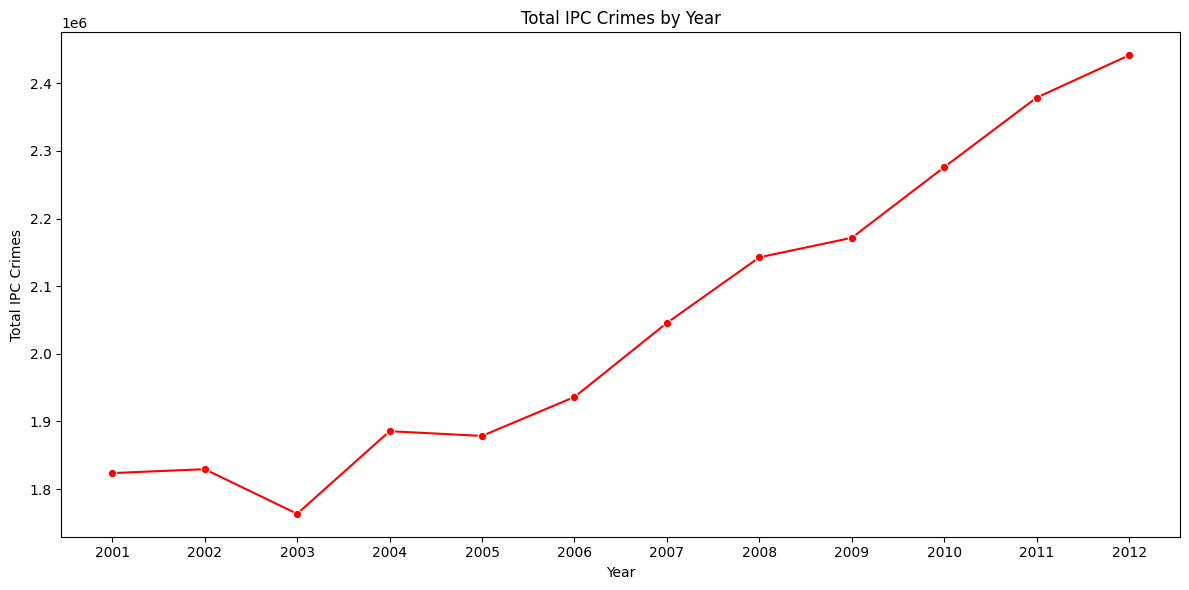

In [186]:
plt.figure(figsize=(12, 6))

sns.lineplot(
    data=yearly_crime,
    x="YEAR",
    y="TOTAL IPC CRIMES",
    marker="o",
    color="red"
)

plt.title("Total IPC Crimes by Year")
plt.xlabel("Year")
plt.ylabel("Total IPC Crimes")
plt.xticks(yearly_crime["YEAR"])

plt.tight_layout()

plt.savefig(
    FIGURES_DIR / "01_total_ipc_crimes_by_year.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

In [187]:
state_crime = (
    df_district
    .groupby("STATE/UT")["TOTAL IPC CRIMES"]
    .sum()
    .sort_values(ascending=False)
    .head(15)
)

display(state_crime.to_frame("TOTAL IPC CRIMES"))

,TOTAL IPC CRIMES
STATE/UT,
MADHYA PRADESH,2413770
MAHARASHTRA,2273436
TAMIL NADU,2060176
ANDHRA PRADESH,2018981
UTTAR PRADESH,1858074
RAJASTHAN,1855916
KARNATAKA,1481063
KERALA,1437459
GUJARAT,1385775


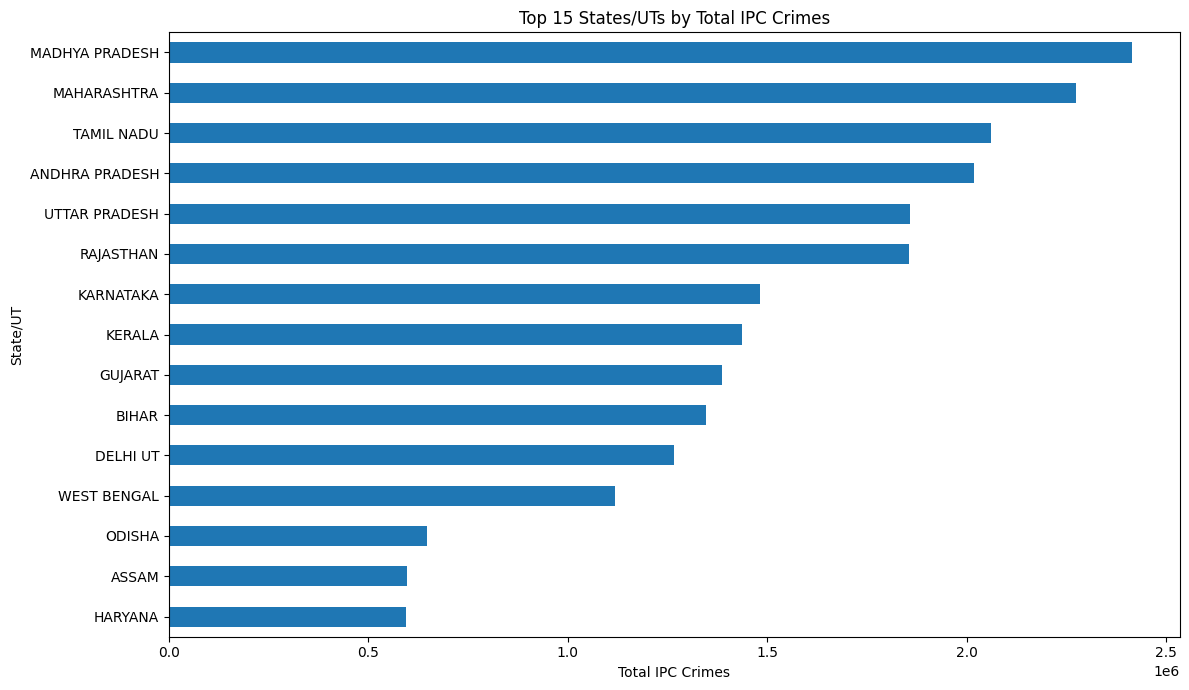

In [188]:
plt.figure(figsize=(12, 7))

state_crime.sort_values().plot(
    kind="barh",
    figsize=(12, 7)
)

plt.title("Top 15 States/UTs by Total IPC Crimes")
plt.xlabel("Total IPC Crimes")
plt.ylabel("State/UT")

plt.tight_layout()

plt.savefig(
    FIGURES_DIR / "02_top_states_total_ipc_crimes.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

In [189]:
crime_totals = (
    df_district[numeric_crime_columns]
    .sum(numeric_only=True)
    .sort_values(ascending=False)
)

display(
    crime_totals.head(20).to_frame(
        "Total Recorded Cases"
    )
)

,Total Recorded Cases
TOTAL IPC CRIMES,24573828
OTHER IPC CRIMES,10040286
THEFT,3732076
HURT/GREVIOUS HURT,3394086
OTHER THEFT,2334689
AUTO THEFT,1397387
BURGLARY,1140894
CAUSING DEATH BY NEGLIGENCE,1009367
CRUELTY BY HUSBAND OR HIS RELATIVES,890412
CHEATING,793725


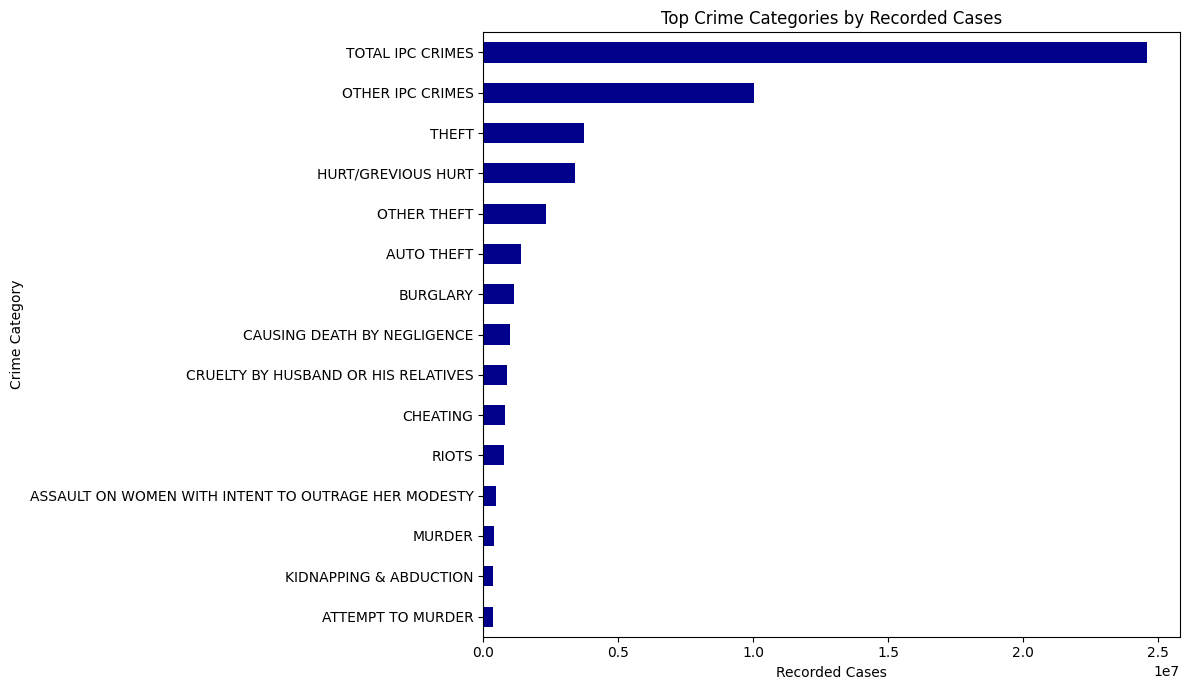

In [190]:
top_crimes = crime_totals.head(15).sort_values()

plt.figure(figsize=(12, 7))

top_crimes.plot(
    kind="barh",
    color="darkblue"
)

plt.title("Top Crime Categories by Recorded Cases")
plt.xlabel("Recorded Cases")
plt.ylabel("Crime Category")

plt.tight_layout()

plt.savefig(
    FIGURES_DIR / "03_top_crime_categories.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

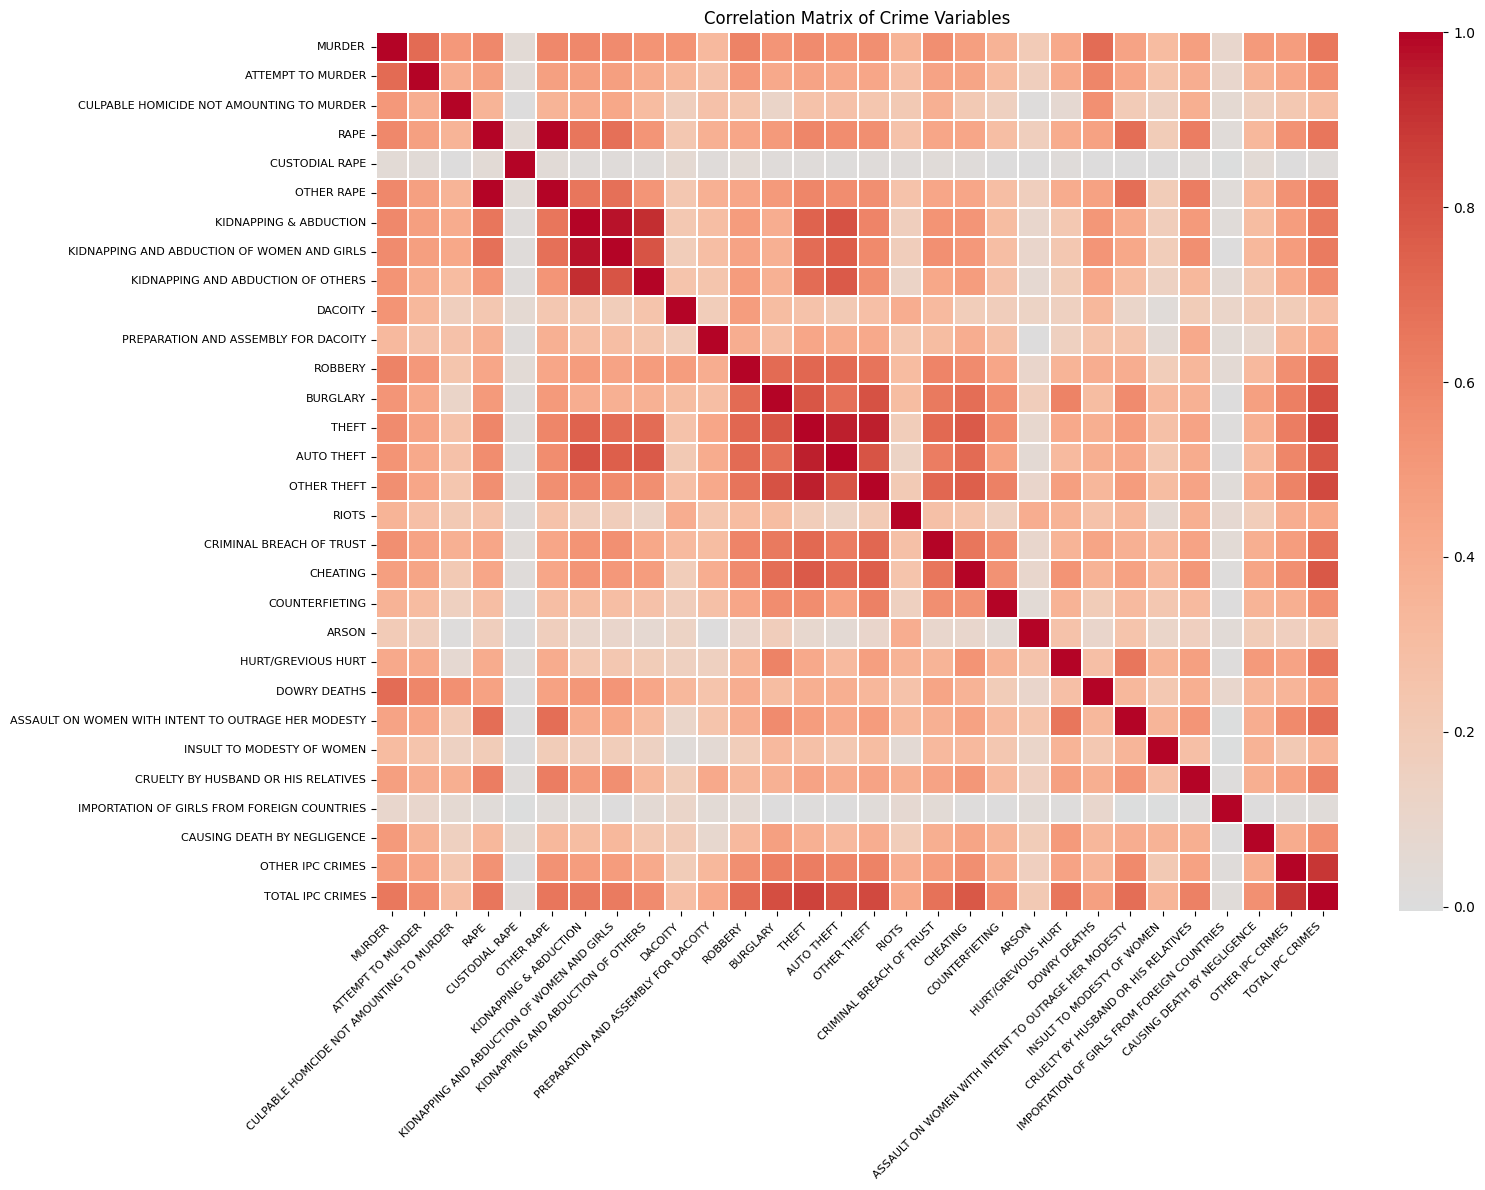

In [191]:
correlation_data = df_district[
    numeric_crime_columns
].copy()

correlation_matrix = correlation_data.corr()

plt.figure(figsize=(16, 12))

sns.heatmap(
    correlation_matrix,
    cmap="coolwarm",
    center=0,
    linewidths=0.2
)
plt.xticks(fontsize=8,rotation=45,ha='right')
plt.yticks(fontsize=8)
plt.title("Correlation Matrix of Crime Variables")

plt.tight_layout()

plt.savefig(
    FIGURES_DIR / "04_crime_correlation_matrix.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

In [192]:
corr_pairs = (
    correlation_matrix
    .where(
        np.triu(
            np.ones(correlation_matrix.shape),
            k=1
        ).astype(bool)
    )
    .stack()
    .reset_index()
)

corr_pairs.columns = [
    "Variable_1",
    "Variable_2",
    "Correlation"
]

corr_pairs["Absolute_Correlation"] = (
    corr_pairs["Correlation"].abs()
)

display(
    corr_pairs
    .sort_values(
        "Absolute_Correlation",
        ascending=False
    )
    .head(20)
)

,Variable_1,Variable_2,Correlation,Absolute_Correlation
85,RAPE,OTHER RAPE,0.999998,0.999998
159,KIDNAPPING & ABDUCTION,KIDNAPPING AND ABDUCTION OF WOMEN AND GIRLS,0.969008,0.969008
300,THEFT,OTHER THEFT,0.948772,0.948772
299,THEFT,AUTO THEFT,0.945386,0.945386
160,KIDNAPPING & ABDUCTION,KIDNAPPING AND ABDUCTION OF OTHERS,0.917295,0.917295
434,OTHER IPC CRIMES,TOTAL IPC CRIMES,0.891539,0.891539
314,THEFT,TOTAL IPC CRIMES,0.854671,0.854671
343,OTHER THEFT,TOTAL IPC CRIMES,0.832581,0.832581
298,BURGLARY,TOTAL IPC CRIMES,0.817797,0.817797
284,BURGLARY,OTHER THEFT,0.802553,0.802553


In [193]:
state_year_crime = (
    df_district
    .groupby(["STATE/UT", "YEAR"], as_index=False)
    [numeric_crime_columns]
    .sum()
)

print(
    "State-Year crime dataset shape:",
    state_year_crime.shape
)

display(
    state_year_crime.head()
)

State-Year crime dataset shape: (420, 32)


,STATE/UT,YEAR,MURDER,ATTEMPT TO MURDER,CULPABLE HOMICIDE NOT AMOUNTING TO MURDER,RAPE,CUSTODIAL RAPE,OTHER RAPE,KIDNAPPING & ABDUCTION,KIDNAPPING AND ABDUCTION OF WOMEN AND GIRLS,KIDNAPPING AND ABDUCTION OF OTHERS,DACOITY,PREPARATION AND ASSEMBLY FOR DACOITY,ROBBERY,BURGLARY,THEFT,AUTO THEFT,OTHER THEFT,RIOTS,CRIMINAL BREACH OF TRUST,CHEATING,COUNTERFIETING,ARSON,HURT/GREVIOUS HURT,DOWRY DEATHS,ASSAULT ON WOMEN WITH INTENT TO OUTRAGE HER MODESTY,INSULT TO MODESTY OF WOMEN,CRUELTY BY HUSBAND OR HIS RELATIVES,IMPORTATION OF GIRLS FROM FOREIGN COUNTRIES,CAUSING DEATH BY NEGLIGENCE,OTHER IPC CRIMES,TOTAL IPC CRIMES
0,A & N ISLANDS,2001,13,0,0,3,0,3,2,2,0,0,0,4,64,65,4,61,13,10,8,2,4,118,0,19,1,9,0,0,323,658
1,A & N ISLANDS,2002,17,3,1,2,0,2,2,1,1,1,0,7,49,49,2,47,11,4,11,0,2,97,0,17,3,4,0,0,328,608
2,A & N ISLANDS,2003,21,4,1,2,0,2,2,2,0,2,0,7,56,60,3,57,19,3,13,0,8,110,0,9,2,7,0,0,318,644
3,A & N ISLANDS,2004,15,1,2,10,0,10,3,3,0,0,0,3,69,103,9,94,9,0,12,0,9,105,0,6,3,5,0,6,387,748
4,A & N ISLANDS,2005,14,3,3,4,0,4,2,1,1,0,0,4,68,92,6,86,4,8,13,0,6,79,0,11,1,5,0,3,362,682


In [194]:
duplicate_state_year = (
    state_year_crime
    .duplicated(
        subset=["STATE/UT", "YEAR"]
    )
    .sum()
)

print(
    "Duplicate STATE/UT + YEAR rows:",
    duplicate_state_year
)

Duplicate STATE/UT + YEAR rows: 0


In [195]:
file_structure = []

for filename, df_temp in dataframes.items():

    columns_upper = {
        str(c).strip().upper(): c
        for c in df_temp.columns
    }

    possible_state = None
    possible_year = None
    possible_district = None

    for candidate in [
        "STATE/UT",
        "STATE",
        "STATE_UT",
        "AREA_NAME"
    ]:

        if candidate in columns_upper:
            possible_state = columns_upper[candidate]
            break

    for candidate in [
        "YEAR",
        "YEAR "
    ]:

        if candidate in columns_upper:
            possible_year = columns_upper[candidate]
            break

    for candidate in [
        "DISTRICT",
        "DISTRICT_NAME"
    ]:

        if candidate in columns_upper:
            possible_district = columns_upper[candidate]
            break

    file_structure.append({
        "File": filename,
        "Rows": len(df_temp),
        "Columns": len(df_temp.columns),
        "State_Column": possible_state,
        "Year_Column": possible_year,
        "District_Column": possible_district
    })

file_structure_df = pd.DataFrame(file_structure)

display(file_structure_df)

,File,Rows,Columns,State_Column,Year_Column,District_Column
0,01_District_wise_crimes_committed_IPC_2001_201...,9017,33,STATE/UT,YEAR,DISTRICT
1,01_District_wise_crimes_committed_IPC_2013.csv,823,33,STATE/UT,YEAR,DISTRICT
2,01_District_wise_crimes_committed_IPC_2014.csv,838,91,None,Year,District
3,02_01_District_wise_crimes_committed_against_S...,9018,13,STATE/UT,Year,DISTRICT
4,02_01_District_wise_crimes_committed_against_S...,823,13,STATE/UT,Year,DISTRICT
5,02_01_District_wise_crimes_committed_against_S...,837,66,None,Year,District
6,02_District_wise_crimes_committed_against_ST_2...,9018,13,STATE/UT,Year,DISTRICT
7,02_District_wise_crimes_committed_against_ST_2...,823,13,STATE/UT,Year,DISTRICT
8,02_District_wise_crimes_committed_against_ST_2...,837,66,None,Year,District
9,03_District_wise_crimes_committed_against_chil...,9015,15,STATE/UT,Year,DISTRICT


In [196]:
file_structure_path = (
    TABLES_DIR / "file_structure_report.csv"
)

file_structure_df.to_csv(
    file_structure_path,
    index=False
)

print(
    "Saved:",
    file_structure_path
)

Saved: D:\Major_Project\Crime_Analysis\outputs\tables\file_structure_report.csv


In [197]:
missing_report = pd.DataFrame({
    "Column": df_main.columns,
    "Missing_Count": df_main.isna().sum().values
})

missing_report["Missing_Percentage"] = (
    missing_report["Missing_Count"]
    / len(df_main)
    * 100
)

missing_report = missing_report.sort_values(
    "Missing_Percentage",
    ascending=False
)

display(missing_report.head(20))

,Column,Missing_Count,Missing_Percentage
0,STATE/UT,0,0.0
17,AUTO THEFT,0,0.0
31,OTHER IPC CRIMES,0,0.0
30,CAUSING DEATH BY NEGLIGENCE,0,0.0
29,IMPORTATION OF GIRLS FROM FOREIGN COUNTRIES,0,0.0
28,CRUELTY BY HUSBAND OR HIS RELATIVES,0,0.0
27,INSULT TO MODESTY OF WOMEN,0,0.0
26,ASSAULT ON WOMEN WITH INTENT TO OUTRAGE HER MO...,0,0.0
25,DOWRY DEATHS,0,0.0
24,HURT/GREVIOUS HURT,0,0.0


In [198]:
district_output = (
    PROCESSED_DIR /
    "district_wise_ipc_crimes_cleaned.csv"
)

df_district.to_csv(
    district_output,
    index=False
)

print(
    "Saved district dataset:",
    district_output
)

Saved district dataset: D:\Major_Project\Crime_Analysis\data\processed\district_wise_ipc_crimes_cleaned.csv


In [199]:
state_year_output = (
    PROCESSED_DIR /
    "state_year_crime_dataset.csv"
)

state_year_crime.to_csv(
    state_year_output,
    index=False
)

print(
    "Saved state-year dataset:",
    state_year_output
)

Saved state-year dataset: D:\Major_Project\Crime_Analysis\data\processed\state_year_crime_dataset.csv


In [200]:
raw_inventory_output = (
    PROCESSED_DIR /
    "all_csv_file_inventory.csv"
)

file_inventory.to_csv(
    raw_inventory_output,
    index=False
)

print(
    "Saved:",
    raw_inventory_output
)

Saved: D:\Major_Project\Crime_Analysis\data\processed\all_csv_file_inventory.csv


In [201]:
print("=" * 70)
print("FINAL NOTEBOOK 01 VALIDATION")
print("=" * 70)

print(
    f"CSV files found              : {len(csv_files)}"
)

print(
    f"CSV files successfully read  : {len(dataframes)}"
)

print(
    f"Files with reading errors    : {len(read_errors)}"
)

print(
    f"Main dataset rows            : {df_main.shape[0]:,}"
)

print(
    f"Main dataset columns        : {df_main.shape[1]}"
)

print(
    f"District dataset rows       : {df_district.shape[0]:,}"
)

print(
    f"State-Year dataset rows     : {state_year_crime.shape[0]:,}"
)

print(
    f"State-Year dataset features : {state_year_crime.shape[1] - 2}"
)

print(
    f"Number of states/UTs        : "
    f"{state_year_crime['STATE/UT'].nunique()}"
)

print(
    f"Year range                  : "
    f"{int(state_year_crime['YEAR'].min())} - "
    f"{int(state_year_crime['YEAR'].max())}"
)

print(
    f"State-Year duplicate rows   : {duplicate_state_year}"
)

print("=" * 70)
print("Notebook 01 completed successfully.")

FINAL NOTEBOOK 01 VALIDATION
CSV files found              : 76
CSV files successfully read  : 76
Files with reading errors    : 0
Main dataset rows            : 9,017
Main dataset columns        : 33
District dataset rows       : 8,609
State-Year dataset rows     : 420
State-Year dataset features : 30
Number of states/UTs        : 35
Year range                  : 2001 - 2012
State-Year duplicate rows   : 0
Notebook 01 completed successfully.


In [202]:
# ============================================================
# MULTI-FILE DATA INTEGRATION
# ============================================================

print("=" * 70)
print("STARTING MULTI-FILE INTEGRATION")
print("=" * 70)

print(f"Files available for integration: {len(dataframes)}")

STARTING MULTI-FILE INTEGRATION
Files available for integration: 76


In [203]:
def normalize_column_for_matching(column):
    """
    Convert a column name into a standard form for matching.
    Example:
    'States/UTs' -> 'STATES_UTS'
    'STATE/UT'   -> 'STATE_UT'
    """
    text = str(column).strip().upper()
    text = re.sub(r"[^A-Z0-9]+", "_", text)
    text = text.strip("_")
    return text


STATE_CANDIDATES = [
    "STATE_UT",
    "STATE",
    "STATE_NAME",
    "STATE_UT_NAME",
    "STATES_UTS",
    "AREA_NAME",
    "AREA"
]

YEAR_CANDIDATES = [
    "YEAR"
]

DISTRICT_CANDIDATES = [
    "DISTRICT",
    "DISTRICT_NAME"
]


def find_matching_column(columns, candidates):
    """
    Find the first matching column from a list of candidates.
    """
    
    normalized_columns = {
        normalize_column_for_matching(col): col
        for col in columns
    }

    for candidate in candidates:
        if candidate in normalized_columns:
            return normalized_columns[candidate]

    return None


print("Column identification functions ready.")

Column identification functions ready.


In [204]:
def standardize_state_name(value):

    if pd.isna(value):
        return np.nan

    value = str(value).strip().upper()

    # Remove extra spaces
    value = re.sub(r"\s+", " ", value)

    # Standardize ampersand
    value = value.replace("&", "AND")

    state_mapping = {

        "A AND N ISLANDS":
            "ANDAMAN AND NICOBAR ISLANDS",

        "AANDN ISLANDS":
            "ANDAMAN AND NICOBAR ISLANDS",

        "ANDAMAN AND NICOBAR ISLANDS":
            "ANDAMAN AND NICOBAR ISLANDS",

        "D AND N HAVELI":
            "DADRA AND NAGAR HAVELI",

        "DANDN HAVELI":
            "DADRA AND NAGAR HAVELI",

        "DADRA AND NAGAR HAVELI":
            "DADRA AND NAGAR HAVELI",

        "DELHI UT":
            "DELHI",

        "ORISSA":
            "ODISHA",

        "PONDICHERRY":
            "PUDUCHERRY",

        "UTTARANCHAL":
            "UTTARAKHAND"
    }

    return state_mapping.get(value, value)


print("State standardization function ready.")

State standardization function ready.


In [205]:
def extract_single_year_from_filename(filename):

    years = re.findall(
        r"(?<!\d)(20\d{2})(?!\d)",
        filename
    )

    # Remove duplicates while preserving order
    years = list(dict.fromkeys(years))

    # Only use the filename if exactly ONE year exists
    if len(years) == 1:
        return int(years[0])

    return None


print("Year extraction function ready.")

Year extraction function ready.


In [206]:
integration_tables = []

integration_report = []

for file_number, (filename, df_original) in enumerate(
    dataframes.items(),
    start=1
):

    print(
        f"[{file_number:02d}/{len(dataframes)}] "
        f"Processing: {filename}"
    )

    df = df_original.copy()

    # --------------------------------------------------------
    # FIND IMPORTANT COLUMNS
    # --------------------------------------------------------

    state_column = find_matching_column(
        df.columns,
        STATE_CANDIDATES
    )

    year_column = find_matching_column(
        df.columns,
        YEAR_CANDIDATES
    )

    district_column = find_matching_column(
        df.columns,
        DISTRICT_CANDIDATES
    )

    # --------------------------------------------------------
    # STATE
    # --------------------------------------------------------

    if state_column is None:

        integration_report.append({
            "File": filename,
            "Status": "Skipped - no State column",
            "State_Column": None,
            "Year_Column": year_column,
            "Rows_Original": len(df),
            "Rows_After_Cleaning": 0,
            "Numeric_Features": 0
        })

        continue

    df["__STATE__"] = df[state_column].apply(
        standardize_state_name
    )

    # --------------------------------------------------------
    # YEAR
    # --------------------------------------------------------

    if year_column is not None:

        df["__YEAR__"] = pd.to_numeric(
            df[year_column],
            errors="coerce"
        )

        year_source = "Column"

    else:

        filename_year = extract_single_year_from_filename(
            filename
        )

        if filename_year is not None:

            df["__YEAR__"] = filename_year
            year_source = "Filename"

        else:

            integration_report.append({
                "File": filename,
                "Status": "Skipped - no usable Year",
                "State_Column": state_column,
                "Year_Column": None,
                "Rows_Original": len(df),
                "Rows_After_Cleaning": 0,
                "Numeric_Features": 0
            })

            continue

    # --------------------------------------------------------
    # REMOVE DISTRICT TOTAL ROWS
    # --------------------------------------------------------

    rows_before_total_removal = len(df)

    if district_column is not None:

        district_text = (
            df[district_column]
            .astype(str)
            .str.strip()
            .str.upper()
        )

        total_mask = district_text.eq("TOTAL")

        # Remove TOTAL only when actual district rows
        # also exist in the same file.
        if total_mask.any() and (~total_mask).any():

            df = df.loc[~total_mask].copy()

    rows_after_total_removal = len(df)

    # --------------------------------------------------------
    # REMOVE INVALID STATE/YEAR
    # --------------------------------------------------------

    df = df[
        df["__STATE__"].notna()
        & df["__YEAR__"].notna()
    ].copy()

    # Remove non-data summary states such as TOTAL
    total_state_mask = (
        df["__STATE__"]
        .astype(str)
        .str.upper()
        .str.startswith("TOTAL")
    )

    df = df.loc[~total_state_mask].copy()

    # --------------------------------------------------------
    # IDENTIFY NUMERIC MEASURES
    # --------------------------------------------------------

    identifier_columns = {
        state_column,
        year_column,
        district_column,
        "__STATE__",
        "__YEAR__"
    }

    identifier_columns = {
        x for x in identifier_columns
        if x is not None
    }

    numeric_columns = []

    for column in df.columns:

        if column in identifier_columns:
            continue

        normalized = normalize_column_for_matching(
            column
        )

        # These are descriptive/categorical fields,
        # not numerical measurements.
        categorical_names = {
            "GROUP_NAME",
            "SUB_GROUP_NAME",
            "GROUP",
            "SUB_GROUP",
            "TYPE",
            "CATEGORY",
            "NAME",
            "CRIME_HEAD"
        }

        if normalized in categorical_names:
            continue

        numeric_version = pd.to_numeric(
            df[column]
            .astype(str)
            .str.replace(",", "", regex=False)
            .str.strip(),
            errors="coerce"
        )

        original_non_missing = df[column].notna().sum()

        if original_non_missing == 0:
            continue

        numeric_ratio = (
            numeric_version.notna().sum()
            / original_non_missing
        )

        # Keep columns where at least 50% of available
        # values can be interpreted numerically.
        if numeric_ratio >= 0.50:

            df[column] = numeric_version

            numeric_columns.append(column)

    # --------------------------------------------------------
    # IF NO NUMERIC MEASURES
    # --------------------------------------------------------

    if len(numeric_columns) == 0:

        integration_report.append({
            "File": filename,
            "Status": "Skipped - no numeric measures",
            "State_Column": state_column,
            "Year_Column": year_source,
            "Rows_Original": len(df_original),
            "Rows_After_Cleaning": len(df),
            "Numeric_Features": 0
        })

        continue

    # --------------------------------------------------------
    # AGGREGATE TO STATE + YEAR
    # --------------------------------------------------------

    grouped = (
        df
        .groupby(
            ["__STATE__", "__YEAR__"],
            dropna=True
        )[numeric_columns]
        .sum(min_count=1)
        .reset_index()
    )

    # --------------------------------------------------------
    # PREFIX FEATURES WITH SOURCE FILE
    # --------------------------------------------------------

    file_prefix = re.sub(
        r"[^A-Za-z0-9]+",
        "_",
        Path(filename).stem
    ).strip("_").upper()

    renamed_columns = {}

    for column in numeric_columns:

        clean_name = re.sub(
            r"[^A-Za-z0-9]+",
            "_",
            str(column)
        ).strip("_").upper()

        new_name = (
            f"{file_prefix}__{clean_name}"
        )

        renamed_columns[column] = new_name

    grouped = grouped.rename(
        columns=renamed_columns
    )

    grouped = grouped.rename(
        columns={
            "__STATE__": "STATE_UT",
            "__YEAR__": "YEAR"
        }
    )

    integration_tables.append(grouped)

    integration_report.append({
        "File": filename,
        "Status": "Integrated",
        "State_Column": state_column,
        "Year_Column": year_source,
        "Rows_Original": len(df_original),
        "Rows_After_Cleaning": len(df),
        "Numeric_Features": len(numeric_columns)
    })

print("\n")
print("=" * 70)
print("INDIVIDUAL FILE PROCESSING COMPLETED")
print("=" * 70)

[01/76] Processing: 01_District_wise_crimes_committed_IPC_2001_2012.csv
[02/76] Processing: 01_District_wise_crimes_committed_IPC_2013.csv
[03/76] Processing: 01_District_wise_crimes_committed_IPC_2014.csv
[04/76] Processing: 02_01_District_wise_crimes_committed_against_SC_2001_2012.csv
[05/76] Processing: 02_01_District_wise_crimes_committed_against_SC_2013.csv
[06/76] Processing: 02_01_District_wise_crimes_committed_against_SC_2014.csv
[07/76] Processing: 02_District_wise_crimes_committed_against_ST_2001_2012.csv
[08/76] Processing: 02_District_wise_crimes_committed_against_ST_2013.csv
[09/76] Processing: 02_District_wise_crimes_committed_against_ST_2014.csv
[10/76] Processing: 03_District_wise_crimes_committed_against_children_2001_2012.csv
[11/76] Processing: 03_District_wise_crimes_committed_against_children_2013.csv
[12/76] Processing: 03_Persons_arrested_and_their_disposal_by_police_and_court_under_crime_against_children_2012.csv
[13/76] Processing: 03_Persons_arrested_and_their

In [207]:
integration_report_df = pd.DataFrame(
    integration_report
)

display(
    integration_report_df
)

,File,Status,State_Column,Year_Column,Rows_Original,Rows_After_Cleaning,Numeric_Features
0,01_District_wise_crimes_committed_IPC_2001_201...,Integrated,STATE/UT,Column,9017,8609,30
1,01_District_wise_crimes_committed_IPC_2013.csv,Integrated,STATE/UT,Column,823,823,30
2,01_District_wise_crimes_committed_IPC_2014.csv,Integrated,States/UTs,Column,838,802,88
3,02_01_District_wise_crimes_committed_against_S...,Integrated,STATE/UT,Column,9018,8597,10
4,02_01_District_wise_crimes_committed_against_S...,Integrated,STATE/UT,Column,823,788,10
5,02_01_District_wise_crimes_committed_against_S...,Integrated,States/UTs,Column,837,801,63
6,02_District_wise_crimes_committed_against_ST_2...,Integrated,STATE/UT,Column,9018,8597,10
7,02_District_wise_crimes_committed_against_ST_2...,Integrated,STATE/UT,Column,823,823,10
8,02_District_wise_crimes_committed_against_ST_2...,Integrated,States/UTs,Column,837,801,63
9,03_District_wise_crimes_committed_against_chil...,Integrated,STATE/UT,Column,9015,8603,12


In [208]:
print(
    integration_report_df["Status"]
    .value_counts()
)

Status
Integrated    76
Name: count, dtype: int64


In [209]:
integrated_file_count = (
    integration_report_df["Status"]
    .eq("Integrated")
    .sum()
)

print(
    "Total CSV files:",
    len(dataframes)
)

print(
    "Successfully integrated:",
    integrated_file_count
)

print(
    "Not integrated:",
    len(dataframes) - integrated_file_count
)

if integrated_file_count == len(dataframes):

    print(
        "\n✓ ALL 76 CSV FILES WERE SUCCESSFULLY INTEGRATED."
    )

else:

    print(
        "\n⚠ Some files were not integrated."
    )

    display(
        integration_report_df[
            integration_report_df["Status"] != "Integrated"
        ]
    )

Total CSV files: 76
Successfully integrated: 76
Not integrated: 0

✓ ALL 76 CSV FILES WERE SUCCESSFULLY INTEGRATED.


In [210]:
master_state_year = integration_tables[0].copy()

for table in integration_tables[1:]:

    master_state_year = master_state_year.merge(
        table,
        on=["STATE_UT", "YEAR"],
        how="outer",
        validate="one_to_one"
    )

print(
    "Initial integrated dataset shape:",
    master_state_year.shape
)

Initial integrated dataset shape: (491, 1249)


In [211]:
master_state_year["STATE_UT"] = (
    master_state_year["STATE_UT"]
    .apply(standardize_state_name)
)

# Remove remaining total/summary state rows
master_state_year = master_state_year[
    ~master_state_year["STATE_UT"]
    .astype(str)
    .str.upper()
    .str.startswith("TOTAL")
].copy()

# Sort
master_state_year = (
    master_state_year
    .sort_values(
        ["STATE_UT", "YEAR"]
    )
    .reset_index(drop=True)
)

print(
    "Dataset after state harmonization:",
    master_state_year.shape
)

Dataset after state harmonization: (491, 1249)


In [212]:
duplicate_keys = (
    master_state_year
    .duplicated(
        subset=["STATE_UT", "YEAR"]
    )
    .sum()
)

print(
    "Duplicate STATE_UT + YEAR combinations:",
    duplicate_keys
)

if duplicate_keys == 0:
    print(
        "✓ Every State-Year combination is unique."
    )
else:
    print(
        "⚠ Duplicate State-Year combinations found."
    )

Duplicate STATE_UT + YEAR combinations: 0
✓ Every State-Year combination is unique.


In [213]:
print(
    "Rows:",
    f"{master_state_year.shape[0]:,}"
)

print(
    "Columns:",
    f"{master_state_year.shape[1]:,}"
)

print("\nFirst 5 rows:")

display(
    master_state_year.head()
)

Rows: 491
Columns: 1,249

First 5 rows:


,STATE_UT,YEAR,01_DISTRICT_WISE_CRIMES_COMMITTED_IPC_2001_2012__MURDER,01_DISTRICT_WISE_CRIMES_COMMITTED_IPC_2001_2012__ATTEMPT_TO_MURDER,01_DISTRICT_WISE_CRIMES_COMMITTED_IPC_2001_2012__CULPABLE_HOMICIDE_NOT_AMOUNTING_TO_MURDER,01_DISTRICT_WISE_CRIMES_COMMITTED_IPC_2001_2012__RAPE,01_DISTRICT_WISE_CRIMES_COMMITTED_IPC_2001_2012__CUSTODIAL_RAPE,01_DISTRICT_WISE_CRIMES_COMMITTED_IPC_2001_2012__OTHER_RAPE,01_DISTRICT_WISE_CRIMES_COMMITTED_IPC_2001_2012__KIDNAPPING_ABDUCTION,01_DISTRICT_WISE_CRIMES_COMMITTED_IPC_2001_2012__KIDNAPPING_AND_ABDUCTION_OF_WOMEN_AND_GIRLS,01_DISTRICT_WISE_CRIMES_COMMITTED_IPC_2001_2012__KIDNAPPING_AND_ABDUCTION_OF_OTHERS,01_DISTRICT_WISE_CRIMES_COMMITTED_IPC_2001_2012__DACOITY,01_DISTRICT_WISE_CRIMES_COMMITTED_IPC_2001_2012__PREPARATION_AND_ASSEMBLY_FOR_DACOITY,01_DISTRICT_WISE_CRIMES_COMMITTED_IPC_2001_2012__ROBBERY,01_DISTRICT_WISE_CRIMES_COMMITTED_IPC_2001_2012__BURGLARY,01_DISTRICT_WISE_CRIMES_COMMITTED_IPC_2001_2012__THEFT,01_DISTRICT_WISE_CRIMES_COMMITTED_IPC_2001_2012__AUTO_THEFT,01_DISTRICT_WISE_CRIMES_COMMITTED_IPC_2001_2012__OTHER_THEFT,01_DISTRICT_WISE_CRIMES_COMMITTED_IPC_2001_2012__RIOTS,01_DISTRICT_WISE_CRIMES_COMMITTED_IPC_2001_2012__CRIMINAL_BREACH_OF_TRUST,01_DISTRICT_WISE_CRIMES_COMMITTED_IPC_2001_2012__CHEATING,01_DISTRICT_WISE_CRIMES_COMMITTED_IPC_2001_2012__COUNTERFIETING,01_DISTRICT_WISE_CRIMES_COMMITTED_IPC_2001_2012__ARSON,01_DISTRICT_WISE_CRIMES_COMMITTED_IPC_2001_2012__HURT_GREVIOUS_HURT,01_DISTRICT_WISE_CRIMES_COMMITTED_IPC_2001_2012__DOWRY_DEATHS,01_DISTRICT_WISE_CRIMES_COMMITTED_IPC_2001_2012__ASSAULT_ON_WOMEN_WITH_INTENT_TO_OUTRAGE_HER_MODESTY,01_DISTRICT_WISE_CRIMES_COMMITTED_IPC_2001_2012__INSULT_TO_MODESTY_OF_WOMEN,01_DISTRICT_WISE_CRIMES_COMMITTED_IPC_2001_2012__CRUELTY_BY_HUSBAND_OR_HIS_RELATIVES,01_DISTRICT_WISE_CRIMES_COMMITTED_IPC_2001_2012__IMPORTATION_OF_GIRLS_FROM_FOREIGN_COUNTRIES,01_DISTRICT_WISE_CRIMES_COMMITTED_IPC_2001_2012__CAUSING_DEATH_BY_NEGLIGENCE,01_DISTRICT_WISE_CRIMES_COMMITTED_IPC_2001_2012__OTHER_IPC_CRIMES,01_DISTRICT_WISE_CRIMES_COMMITTED_IPC_2001_2012__TOTAL_IPC_CRIMES,01_DISTRICT_WISE_CRIMES_COMMITTED_IPC_2013__MURDER,01_DISTRICT_WISE_CRIMES_COMMITTED_IPC_2013__ATTEMPT_TO_MURDER,01_DISTRICT_WISE_CRIMES_COMMITTED_IPC_2013__CULPABLE_HOMICIDE_NOT_AMOUNTING_TO_MURDER,01_DISTRICT_WISE_CRIMES_COMMITTED_IPC_2013__RAPE,01_DISTRICT_WISE_CRIMES_COMMITTED_IPC_2013__CUSTODIAL_RAPE,01_DISTRICT_WISE_CRIMES_COMMITTED_IPC_2013__OTHER_RAPE,01_DISTRICT_WISE_CRIMES_COMMITTED_IPC_2013__KIDNAPPING_ABDUCTION,01_DISTRICT_WISE_CRIMES_COMMITTED_IPC_2013__KIDNAPPING_AND_ABDUCTION_OF_WOMEN_AND_GIRLS,01_DISTRICT_WISE_CRIMES_COMMITTED_IPC_2013__KIDNAPPING_AND_ABDUCTION_OF_OTHERS,01_DISTRICT_WISE_CRIMES_COMMITTED_IPC_2013__DACOITY,01_DISTRICT_WISE_CRIMES_COMMITTED_IPC_2013__PREPARATION_AND_ASSEMBLY_FOR_DACOITY,01_DISTRICT_WISE_CRIMES_COMMITTED_IPC_2013__ROBBERY,01_DISTRICT_WISE_CRIMES_COMMITTED_IPC_2013__BURGLARY,01_DISTRICT_WISE_CRIMES_COMMITTED_IPC_2013__THEFT,01_DISTRICT_WISE_CRIMES_COMMITTED_IPC_2013__AUTO_THEFT,01_DISTRICT_WISE_CRIMES_COMMITTED_IPC_2013__OTHER_THEFT,01_DISTRICT_WISE_CRIMES_COMMITTED_IPC_2013__RIOTS,01_DISTRICT_WISE_CRIMES_COMMITTED_IPC_2013__CRIMINAL_BREACH_OF_TRUST,...,42_DISTRICT_WISE_CRIMES_COMMITTED_AGAINST_WOMEN_2014__INSULT_TO_THE_MODESTY_OF_WOMEN_TOTAL,42_DISTRICT_WISE_CRIMES_COMMITTED_AGAINST_WOMEN_2014__AT_OFFICE_PREMISES,42_DISTRICT_WISE_CRIMES_COMMITTED_AGAINST_WOMEN_2014__IN_PLACES_RELATED_TO_WORK,42_DISTRICT_WISE_CRIMES_COMMITTED_AGAINST_WOMEN_2014__IN_PUBLIC_TRANSPORT_SYSTEM,42_DISTRICT_WISE_CRIMES_COMMITTED_AGAINST_WOMEN_2014__IN_OTHER_PLACES,42_DISTRICT_WISE_CRIMES_COMMITTED_AGAINST_WOMEN_2014__CRUELTY_BY_HUSBAND_OR_HIS_RELATIVES,42_DISTRICT_WISE_CRIMES_COMMITTED_AGAINST_WOMEN_2014__IMPORTATION_OF_GIRLS_FROM_FOREIGN_COUNTRY,42_DISTRICT_WISE_CRIMES_COMMITTED_AGAINST_WOMEN_2014__MURDER,42_DISTRICT_WISE_CRIMES_COMMITTED_AGAINST_WOMEN_2014__ATTEMPT_TO_COMMIT_MURDER,42_DISTRICT_WISE_CRIMES_COMMITTED_AGAINST_WOMEN_2014__CULPABLE_HOMICIDE_NOT

In [214]:
print(
    "Total columns:",
    len(master_state_year.columns)
)

print("\nFirst 50 columns:")

for column in master_state_year.columns[:50]:
    print(column)

Total columns: 1249

First 50 columns:
STATE_UT
YEAR
01_DISTRICT_WISE_CRIMES_COMMITTED_IPC_2001_2012__MURDER
01_DISTRICT_WISE_CRIMES_COMMITTED_IPC_2001_2012__ATTEMPT_TO_MURDER
01_DISTRICT_WISE_CRIMES_COMMITTED_IPC_2001_2012__CULPABLE_HOMICIDE_NOT_AMOUNTING_TO_MURDER
01_DISTRICT_WISE_CRIMES_COMMITTED_IPC_2001_2012__RAPE
01_DISTRICT_WISE_CRIMES_COMMITTED_IPC_2001_2012__CUSTODIAL_RAPE
01_DISTRICT_WISE_CRIMES_COMMITTED_IPC_2001_2012__OTHER_RAPE
01_DISTRICT_WISE_CRIMES_COMMITTED_IPC_2001_2012__KIDNAPPING_ABDUCTION
01_DISTRICT_WISE_CRIMES_COMMITTED_IPC_2001_2012__KIDNAPPING_AND_ABDUCTION_OF_WOMEN_AND_GIRLS
01_DISTRICT_WISE_CRIMES_COMMITTED_IPC_2001_2012__KIDNAPPING_AND_ABDUCTION_OF_OTHERS
01_DISTRICT_WISE_CRIMES_COMMITTED_IPC_2001_2012__DACOITY
01_DISTRICT_WISE_CRIMES_COMMITTED_IPC_2001_2012__PREPARATION_AND_ASSEMBLY_FOR_DACOITY
01_DISTRICT_WISE_CRIMES_COMMITTED_IPC_2001_2012__ROBBERY
01_DISTRICT_WISE_CRIMES_COMMITTED_IPC_2001_2012__BURGLARY
01_DISTRICT_WISE_CRIMES_COMMITTED_IPC_2001_2012__T

In [215]:
print(
    "Number of States/UTs:",
    master_state_year["STATE_UT"].nunique()
)

print(
    "Minimum Year:",
    int(master_state_year["YEAR"].min())
)

print(
    "Maximum Year:",
    int(master_state_year["YEAR"].max())
)

print("\nStates/UTs:")

display(
    pd.DataFrame({
        "STATE_UT": sorted(
            master_state_year["STATE_UT"].dropna().unique()
        )
    })
)

Number of States/UTs: 36
Minimum Year: 2001
Maximum Year: 2014

States/UTs:


,STATE_UT
0,ANDAMAN AND NICOBAR ISLANDS
1,ANDHRA PRADESH
2,ARUNACHAL PRADESH
3,ASSAM
4,BIHAR
5,CHANDIGARH
6,CHHATTISGARH
7,DADRA AND NAGAR HAVELI
8,DAMAN AND DIU
9,DELHI


In [216]:
missing_master = pd.DataFrame({
    "Column": master_state_year.columns,
    "Missing_Count": master_state_year.isna().sum().values
})

missing_master["Missing_Percentage"] = (
    missing_master["Missing_Count"]
    / len(master_state_year)
    * 100
)

missing_master = (
    missing_master
    .sort_values(
        "Missing_Percentage",
        ascending=False
    )
    .reset_index(drop=True)
)

print(
    "Total missing cells:",
    f"{master_state_year.isna().sum().sum():,}"
)

display(
    missing_master.head(30)
)

Total missing cells: 422,925


,Column,Missing_Count,Missing_Percentage
0,07_02_PERSONS_ARRESTED_BY_SEX_AND_AGE_GROUP_SL...,456,92.87169
1,07_01_PERSONS_ARRESTED_BY_SEX_AND_AGE_GROUP_IP...,456,92.87169
2,04_01_PERSON_ARRESTED_AND_THEIR_DISPOSAL_BY_PO...,456,92.87169
3,04_01_PERSON_ARRESTED_AND_THEIR_DISPOSAL_BY_PO...,456,92.87169
4,04_01_PERSON_ARRESTED_AND_THEIR_DISPOSAL_BY_PO...,456,92.87169
5,04_01_PERSON_ARRESTED_AND_THEIR_DISPOSAL_BY_PO...,456,92.87169
6,04_01_PERSON_ARRESTED_AND_THEIR_DISPOSAL_BY_PO...,456,92.87169
7,04_01_PERSON_ARRESTED_AND_THEIR_DISPOSAL_BY_PO...,456,92.87169
8,04_01_PERSON_ARRESTED_AND_THEIR_DISPOSAL_BY_PO...,456,92.87169
9,04_01_PERSON_ARRESTED_AND_THEIR_DISPOSAL_BY_PO...,456,92.87169


In [217]:
missing_percentage = (
    missing_master["Missing_Percentage"]
)

print(
    "Features with 0% missing:",
    (missing_percentage == 0).sum()
)

print(
    "Features with <= 25% missing:",
    (missing_percentage <= 25).sum()
)

print(
    "Features with <= 50% missing:",
    (missing_percentage <= 50).sum()
)

print(
    "Features with > 50% missing:",
    (missing_percentage > 50).sum()
)

print(
    "Features with > 90% missing:",
    (missing_percentage > 90).sum()
)

Features with 0% missing: 2
Features with <= 25% missing: 111
Features with <= 50% missing: 424
Features with > 50% missing: 825
Features with > 90% missing: 779


In [218]:
before_columns = master_state_year.shape[1]

all_missing_columns = [
    column
    for column in master_state_year.columns
    if master_state_year[column].isna().all()
]

master_state_year = master_state_year.drop(
    columns=all_missing_columns
)

after_columns = master_state_year.shape[1]

print(
    "Completely empty columns removed:",
    len(all_missing_columns)
)

print(
    "Columns before:",
    before_columns
)

print(
    "Columns after:",
    after_columns
)

Completely empty columns removed: 0
Columns before: 1249
Columns after: 1249


In [219]:
feature_columns = [
    column
    for column in master_state_year.columns
    if column not in ["STATE_UT", "YEAR"]
]

constant_columns = []

for column in feature_columns:

    if master_state_year[column].nunique(
        dropna=True
    ) <= 1:

        constant_columns.append(column)

master_state_year = master_state_year.drop(
    columns=constant_columns
)

print(
    "Constant features removed:",
    len(constant_columns)
)

print(
    "Final columns after basic cleaning:",
    master_state_year.shape[1]
)

Constant features removed: 19
Final columns after basic cleaning: 1230


In [220]:
duplicate_rows = (
    master_state_year
    .duplicated()
    .sum()
)

print(
    "Duplicate complete rows:",
    duplicate_rows
)

Duplicate complete rows: 0


In [221]:
MASTER_OUTPUT = (
    PROCESSED_DIR /
    "MASTER_STATE_YEAR_INTEGRATED.csv"
)

master_state_year.to_csv(
    MASTER_OUTPUT,
    index=False
)

print(
    "✓ MASTER DATASET SAVED"
)

print(
    MASTER_OUTPUT
)

✓ MASTER DATASET SAVED
D:\Major_Project\Crime_Analysis\data\processed\MASTER_STATE_YEAR_INTEGRATED.csv


In [222]:
INTEGRATION_REPORT_OUTPUT = (
    TABLES_DIR /
    "multi_file_integration_report.csv"
)

integration_report_df.to_csv(
    INTEGRATION_REPORT_OUTPUT,
    index=False
)

print(
    "Integration report saved:"
)

print(
    INTEGRATION_REPORT_OUTPUT
)

Integration report saved:
D:\Major_Project\Crime_Analysis\outputs\tables\multi_file_integration_report.csv


In [223]:
MISSING_REPORT_OUTPUT = (
    TABLES_DIR /
    "master_dataset_missing_values.csv"
)

missing_master.to_csv(
    MISSING_REPORT_OUTPUT,
    index=False
)

print(
    "Missing-value report saved:"
)

print(
    MISSING_REPORT_OUTPUT
)

Missing-value report saved:
D:\Major_Project\Crime_Analysis\outputs\tables\master_dataset_missing_values.csv


In [224]:
print("=" * 75)
print("FINAL MASTER DATASET VALIDATION")
print("=" * 75)

print(
    f"Original CSV files              : {len(dataframes)}"
)

print(
    f"Successfully integrated         : "
    f"{integrated_file_count}"
)

print(
    f"Master dataset rows             : "
    f"{master_state_year.shape[0]:,}"
)

print(
    f"Master dataset columns          : "
    f"{master_state_year.shape[1]:,}"
)

print(
    f"ML features before Notebook 02  : "
    f"{master_state_year.shape[1] - 2:,}"
)

print(
    f"States/UTs                      : "
    f"{master_state_year['STATE_UT'].nunique()}"
)

print(
    f"Year range                      : "
    f"{int(master_state_year['YEAR'].min())} - "
    f"{int(master_state_year['YEAR'].max())}"
)

print(
    f"Duplicate State-Year keys       : "
    f"{master_state_year.duplicated(['STATE_UT', 'YEAR']).sum()}"
)

print(
    f"Duplicate complete rows         : "
    f"{master_state_year.duplicated().sum()}"
)

print(
    f"Missing cells                   : "
    f"{master_state_year.isna().sum().sum():,}"
)

print("=" * 75)

if integrated_file_count == 76:

    print(
        "✓ ALL 76 CSV FILES ARE INTEGRATED."
    )

else:

    print(
        "⚠ CHECK THE INTEGRATION REPORT."
    )

print(
    "✓ Notebook 01 integration stage completed."
)

FINAL MASTER DATASET VALIDATION
Original CSV files              : 76
Successfully integrated         : 76
Master dataset rows             : 491
Master dataset columns          : 1,230
ML features before Notebook 02  : 1,228
States/UTs                      : 36
Year range                      : 2001 - 2014
Duplicate State-Year keys       : 0
Duplicate complete rows         : 0
Missing cells                   : 414,280
✓ ALL 76 CSV FILES ARE INTEGRATED.
✓ Notebook 01 integration stage completed.


# Multi-File Integration — Final Result

All 76 CSV files from the Crime in India dataset were successfully
read, validated and integrated.

Because the individual CSV files have different structures and
observation levels, direct row-wise concatenation was not appropriate.

Instead, the datasets were standardized and integrated using a common
State/UT + Year analytical level.

District-level datasets were aggregated after removing existing
district-level TOTAL rows to prevent double counting.

Numerical measures from different source files were retained as
source-specific features using file-name prefixes.

The resulting MASTER_STATE_YEAR_INTEGRATED.csv dataset will be used
as the basis for feature engineering and machine learning.

Missing values were retained at this stage because absence of data in
a particular source/year does not necessarily represent zero.

The final target variable and machine-learning feature selection will
be performed in Notebook 02 after further analysis.

In [1]:
from pathlib import Path
import pandas as pd
import numpy as np
import csv
import io
import re
import warnings

warnings.filterwarnings("ignore")

# Project paths
PROJECT_ROOT = Path(r"D:\Major_Project\Crime_Analysis")

RAW_DIR = PROJECT_ROOT / "data" / "raw" / "crime_data"
PROCESSED_DIR = PROJECT_ROOT / "data" / "processed"
OUTPUT_DIR = PROJECT_ROOT / "outputs" / "tables"

OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

print("Raw data folder :", RAW_DIR)
print("Files found     :", len(list(RAW_DIR.glob("*.csv"))))

Raw data folder : D:\Major_Project\Crime_Analysis\data\raw\crime_data
Files found     : 76


In [2]:
def read_csv_with_audit(file_path):
    """
    Reads a CSV using csv.reader so malformed rows can be detected.
    Repairs rows with extra commas only when the file has a
    Sub_Group_Name column and the extra fields occur inside that text field.
    """

    with open(file_path, "r", encoding="utf-8-sig", errors="replace") as f:
        text = f.read()

    reader = csv.reader(io.StringIO(text))
    all_rows = list(reader)

    if not all_rows:
        return None, {}

    header = all_rows[0]
    expected_fields = len(header)

    has_subgroup = "Sub_Group_Name" in header

    repaired_rows = []
    malformed_rows = 0
    repaired_rows_count = 0
    unresolved_rows = 0

    for row in all_rows[1:]:

        # Ignore completely blank lines
        if not row or all(str(x).strip() == "" for x in row):
            continue

        original_len = len(row)

        if original_len == expected_fields:
            repaired_rows.append(row)
            continue

        malformed_rows += 1

        # Repair known structure:
        # Area_Name, Year, Group_Name, Sub_Group_Name, numeric columns...
        if original_len > expected_fields and has_subgroup:

            tail_count = expected_fields - 4

            if tail_count >= 0:

                start = 3
                end = original_len - tail_count

                subgroup_value = ",".join(row[start:end])

                repaired = (
                    row[:start]
                    + [subgroup_value]
                    + row[end:]
                )

                if len(repaired) == expected_fields:
                    repaired_rows.append(repaired)
                    repaired_rows_count += 1
                    continue

        # If we cannot safely repair it
        unresolved_rows += 1

    df = pd.DataFrame(repaired_rows, columns=header)

    audit = {
        "original_physical_data_rows": len(all_rows) - 1,
        "usable_rows_after_reading": len(df),
        "expected_columns": expected_fields,
        "malformed_rows_detected": malformed_rows,
        "rows_repaired": repaired_rows_count,
        "unresolved_rows": unresolved_rows
    }

    return df, audit

In [3]:
def detect_state_column(df):
    candidates = [
        "STATE/UT",
        "States/UTs",
        "State",
        "STATE",
        "Area_Name",
        "AREA_NAME"
    ]

    for col in candidates:
        if col in df.columns:
            return col

    return None


def detect_year_column(df):
    candidates = [
        "Year",
        "YEAR",
        "year"
    ]

    for col in candidates:
        if col in df.columns:
            return col

    return None


def detect_district_column(df):
    for col in df.columns:
        if str(col).strip().lower() == "district":
            return col

    return None


def classify_granularity(df):
    district_col = detect_district_column(df)

    if district_col:
        return "District-level"

    if "Sub_Group_Name" in df.columns or "Group_Name" in df.columns:
        return "State/Year + Category/Group"

    return "State/Year level"

In [4]:
audit_results = []

csv_files = sorted(RAW_DIR.glob("*.csv"))

print("Auditing", len(csv_files), "CSV files...\n")

for i, file_path in enumerate(csv_files, start=1):

    try:

        df, read_audit = read_csv_with_audit(file_path)

        if df is None:
            print(f"[{i}/76] FAILED:", file_path.name)
            continue

        state_col = detect_state_column(df)
        year_col = detect_year_column(df)
        district_col = detect_district_column(df)

        # ------------------------------------------------
        # YEAR INFORMATION
        # ------------------------------------------------

        filename_years = sorted(
            set(
                int(x)
                for x in re.findall(
                    r"(?<!\d)(20\d{2})(?!\d)",
                    file_path.name
                )
            )
        )

        if year_col:

            year_values = pd.to_numeric(
                df[year_col],
                errors="coerce"
            ).dropna()

            if len(year_values) > 0:
                min_year = int(year_values.min())
                max_year = int(year_values.max())
                unique_years = sorted(
                    year_values.astype(int).unique().tolist()
                )
                year_source = "Year column"

            else:
                min_year = None
                max_year = None
                unique_years = []
                year_source = "Year column unusable"

        elif len(filename_years) == 1:

            min_year = filename_years[0]
            max_year = filename_years[0]
            unique_years = filename_years
            year_source = "Filename"

        else:

            min_year = None
            max_year = None
            unique_years = filename_years
            year_source = "Filename ambiguous"

        # ------------------------------------------------
        # STATE INFORMATION
        # ------------------------------------------------

        if state_col:

            states = (
                df[state_col]
                .dropna()
                .astype(str)
                .str.strip()
            )

            unique_states = states.nunique()

            total_rows = int(
                states.str.contains(
                    r"^TOTAL",
                    case=False,
                    regex=True,
                    na=False
                ).sum()
            )

        else:

            unique_states = 0
            total_rows = 0

        # ------------------------------------------------
        # STATE-YEAR DUPLICATES
        # ------------------------------------------------

        if state_col and year_col:

            temp = pd.DataFrame({
                "STATE": df[state_col].astype(str).str.strip(),
                "YEAR": pd.to_numeric(
                    df[year_col],
                    errors="coerce"
                )
            })

            temp = temp.dropna(subset=["YEAR"])

            unique_state_years = len(
                temp.drop_duplicates()
            )

            duplicate_state_year_rows = int(
                temp.duplicated(
                    subset=["STATE", "YEAR"]
                ).sum()
            )

        elif state_col and len(filename_years) == 1:

            temp = pd.DataFrame({
                "STATE": df[state_col].astype(str).str.strip(),
                "YEAR": filename_years[0]
            })

            unique_state_years = len(
                temp.drop_duplicates()
            )

            duplicate_state_year_rows = int(
                temp.duplicated(
                    subset=["STATE", "YEAR"]
                ).sum()
            )

        else:

            unique_state_years = 0
            duplicate_state_year_rows = 0

        # ------------------------------------------------
        # MISSING VALUES
        # ------------------------------------------------

        total_cells = df.shape[0] * df.shape[1]

        missing_cells = int(
            df.isna().sum().sum()
        )

        missing_percentage = (
            missing_cells / total_cells * 100
            if total_cells > 0
            else 0
        )

        # ------------------------------------------------
        # DUPLICATE COMPLETE ROWS
        # ------------------------------------------------

        duplicate_complete_rows = int(
            df.duplicated().sum()
        )

        # ------------------------------------------------
        # NUMERIC COLUMNS
        # ------------------------------------------------

        numeric_columns = int(
            df.apply(
                lambda col: pd.to_numeric(
                    col,
                    errors="coerce"
                ).notna().sum() > 0
            ).sum()
        )

        # ------------------------------------------------
        # STORE RESULT
        # ------------------------------------------------

        audit_results.append({

            "File": file_path.name,

            "Rows": len(df),

            "Columns": len(df.columns),

            "Granularity": classify_granularity(df),

            "State_Column": state_col,

            "Year_Column": year_col,

            "Year_Source": year_source,

            "Min_Year": min_year,

            "Max_Year": max_year,

            "Number_of_Years": len(unique_years),

            "Unique_States": unique_states,

            "Unique_State_Year_Keys": unique_state_years,

            "Duplicate_State_Year_Rows":
                duplicate_state_year_rows,

            "Total_Summary_Rows":
                total_rows,

            "Duplicate_Complete_Rows":
                duplicate_complete_rows,

            "Numeric_Columns":
                numeric_columns,

            "Missing_Cells":
                missing_cells,

            "Missing_Percentage":
                round(missing_percentage, 2),

            "Malformed_Rows":
                read_audit["malformed_rows_detected"],

            "Rows_Repaired":
                read_audit["rows_repaired"],

            "Unresolved_Rows":
                read_audit["unresolved_rows"]
        })

        print(
            f"[{i}/76] {file_path.name} ✓"
        )

    except Exception as e:

        audit_results.append({
            "File": file_path.name,
            "ERROR": str(e)
        })

        print(
            f"[{i}/76] {file_path.name} ❌ {e}"
        )


audit_df = pd.DataFrame(audit_results)

print("\n" + "=" * 70)
print("76-FILE AUDIT COMPLETED")
print("=" * 70)

print("Files audited :", len(audit_df))
print("Total rows    :", audit_df["Rows"].sum())
print("Total columns :", audit_df["Columns"].sum())

Auditing 76 CSV files...

[1/76] 01_District_wise_crimes_committed_IPC_2001_2012.csv ✓
[2/76] 01_District_wise_crimes_committed_IPC_2013.csv ✓
[3/76] 01_District_wise_crimes_committed_IPC_2014.csv ✓
[4/76] 02_01_District_wise_crimes_committed_against_SC_2001_2012.csv ✓
[5/76] 02_01_District_wise_crimes_committed_against_SC_2013.csv ✓
[6/76] 02_01_District_wise_crimes_committed_against_SC_2014.csv ✓
[7/76] 02_District_wise_crimes_committed_against_ST_2001_2012.csv ✓
[8/76] 02_District_wise_crimes_committed_against_ST_2013.csv ✓
[9/76] 02_District_wise_crimes_committed_against_ST_2014.csv ✓
[10/76] 03_District_wise_crimes_committed_against_children_2001_2012.csv ✓
[11/76] 03_District_wise_crimes_committed_against_children_2013.csv ✓
[12/76] 03_Persons_arrested_and_their_disposal_by_police_and_court_under_crime_against_children_2012.csv ✓
[13/76] 03_Persons_arrested_and_their_disposal_by_police_and_court_under_crime_against_children_2013.csv ✓
[14/76] 03_Persons_arrested_and_their_disposa

In [5]:
print("\nFILE AUDIT SUMMARY")
print("=" * 70)

print(
    audit_df[
        [
            "File",
            "Rows",
            "Columns",
            "Granularity",
            "Year_Source",
            "Min_Year",
            "Max_Year",
            "Unique_States",
            "Unique_State_Year_Keys",
            "Duplicate_State_Year_Rows",
            "Total_Summary_Rows",
            "Missing_Percentage",
            "Malformed_Rows",
            "Rows_Repaired",
            "Unresolved_Rows"
        ]
    ].to_string(index=False)
)


FILE AUDIT SUMMARY
                                                                                            File  Rows  Columns                 Granularity Year_Source  Min_Year  Max_Year  Unique_States  Unique_State_Year_Keys  Duplicate_State_Year_Rows  Total_Summary_Rows  Missing_Percentage  Malformed_Rows  Rows_Repaired  Unresolved_Rows
                                             01_District_wise_crimes_committed_IPC_2001_2012.csv  9017       33              District-level Year column      2001      2012             35                     420                       8597                   0                 0.0               0              0                0
                                                  01_District_wise_crimes_committed_IPC_2013.csv   823       33              District-level Year column      2013      2013             35                      35                        788                   0                 0.0               0              0                0
  

In [6]:
print("\nFILES WITH MALFORMED / REPAIRED ROWS")
print("=" * 70)

print(
    audit_df[
        audit_df["Malformed_Rows"] > 0
    ][
        [
            "File",
            "Malformed_Rows",
            "Rows_Repaired",
            "Unresolved_Rows"
        ]
    ].to_string(index=False)
)


print("\nFILES WITH UNRESOLVED ROWS")
print("=" * 70)

print(
    audit_df[
        audit_df["Unresolved_Rows"] > 0
    ][
        [
            "File",
            "Unresolved_Rows"
        ]
    ].to_string(index=False)
)


print("\nFILES USING FILENAME FOR YEAR")
print("=" * 70)

print(
    audit_df[
        audit_df["Year_Source"] == "Filename"
    ][
        [
            "File",
            "Rows",
            "Columns",
            "Min_Year",
            "Max_Year"
        ]
    ].to_string(index=False)
)


FILES WITH MALFORMED / REPAIRED ROWS
                                    File  Malformed_Rows  Rows_Repaired  Unresolved_Rows
                   36_Police_housing.csv             348            348                0
  42_Cases_under_crime_against_women.csv            1400           1400                0
43_Arrests_under_crime_against_women.csv            1400           1400                0

FILES WITH UNRESOLVED ROWS
Empty DataFrame
Columns: [File, Unresolved_Rows]
Index: []

FILES USING FILENAME FOR YEAR
                                                                                            File  Rows  Columns  Min_Year  Max_Year
03_Persons_arrested_and_their_disposal_by_police_and_court_under_crime_against_children_2012.csv   494       14      2012      2012
03_Persons_arrested_and_their_disposal_by_police_and_court_under_crime_against_children_2013.csv   494       14      2013      2013
                 04_01_Person_arrested_and_their_disposal_by_police_and_court_SLL_crime_2012

In [7]:
state_labels = []

for file_path in csv_files:

    df, _ = read_csv_with_audit(file_path)

    if df is None:
        continue

    state_col = detect_state_column(df)

    if state_col:

        for state in (
            df[state_col]
            .dropna()
            .astype(str)
            .str.strip()
            .unique()
        ):

            state_labels.append({
                "File": file_path.name,
                "State_Column": state_col,
                "Raw_State_Label": state
            })


state_labels_df = pd.DataFrame(state_labels)

print(
    "Total distinct raw State/UT labels:",
    state_labels_df["Raw_State_Label"].nunique()
)

print("\nRAW STATE/UT LABELS")
print("=" * 70)

print(
    sorted(
        state_labels_df[
            "Raw_State_Label"
        ].unique()
    )
)

Total distinct raw State/UT labels: 84

RAW STATE/UT LABELS
['A & N ISLANDS', 'A & N Islands', 'A&N Islands', 'ANDHRA PRADESH', 'ARUNACHAL PRADESH', 'ASSAM', 'Andaman & Nicobar Islands', 'Andhra Pradesh', 'Arunachal Pradesh', 'Assam', 'BIHAR', 'Bihar', 'CHANDIGARH', 'CHHATTISGARH', 'Chandigarh', 'Chhattisgarh', 'D & N HAVELI', 'D&N Haveli', 'DAMAN & DIU', 'DELHI', 'DELHI UT', 'Dadra & Nagar Haveli', 'Daman & Diu', 'Delhi', 'Delhi UT', 'GOA', 'GUJARAT', 'Goa', 'Gujarat', 'HARYANA', 'HIMACHAL PRADESH', 'Haryana', 'Himachal Pradesh', 'JAMMU & KASHMIR', 'JHARKHAND', 'Jammu & Kashmir', 'Jharkhand', 'KARNATAKA', 'KERALA', 'Karnataka', 'Kerala', 'LAKSHADWEEP', 'Lakshadweep', 'MADHYA PRADESH', 'MAHARASHTRA', 'MANIPUR', 'MEGHALAYA', 'MIZORAM', 'Madhya Pradesh', 'Maharashtra', 'Manipur', 'Meghalaya', 'Mizoram', 'NAGALAND', 'Nagaland', 'ODISHA', 'Odisha', 'PUDUCHERRY', 'PUNJAB', 'Puducherry', 'Punjab', 'RAJASTHAN', 'Rajasthan', 'SIKKIM', 'Sikkim', 'TAMIL NADU', 'TOTAL (ALL-INDIA)', 'TOTAL (STATES

In [8]:
MASTER_FILE = (
    PROCESSED_DIR /
    "MASTER_STATE_YEAR_INTEGRATED.csv"
)

master = pd.read_csv(
    MASTER_FILE,
    low_memory=False
)

print("=" * 70)
print("CURRENT MASTER DATASET AUDIT")
print("=" * 70)

print("Shape:", master.shape)

print(
    "Rows:",
    master.shape[0]
)

print(
    "Columns:",
    master.shape[1]
)

print(
    "Missing cells:",
    master.isna().sum().sum()
)

print(
    "Missing percentage:",
    round(
        master.isna().sum().sum()
        /
        (master.shape[0] * master.shape[1])
        * 100,
        2
    ),
    "%"
)

print(
    "Duplicate complete rows:",
    master.duplicated().sum()
)

print(
    "Duplicate State-Year keys:",
    master.duplicated(
        subset=["STATE_UT", "YEAR"]
    ).sum()
)

CURRENT MASTER DATASET AUDIT
Shape: (491, 1230)
Rows: 491
Columns: 1230
Missing cells: 414280
Missing percentage: 68.6 %
Duplicate complete rows: 0
Duplicate State-Year keys: 0


In [9]:
master_missing = (
    master.isna()
    .sum()
    .sort_values(ascending=False)
)

master_missing_pct = (
    master.isna()
    .mean()
    .mul(100)
    .sort_values(ascending=False)
)

master_missing_report = pd.DataFrame({
    "Column": master_missing.index,
    "Missing_Cells": master_missing.values,
    "Missing_Percentage": master_missing_pct.values
})

print("\nTOP 30 MOST MISSING COLUMNS")
print("=" * 70)

print(
    master_missing_report
    .head(30)
    .to_string(index=False)
)


print("\nMISSINGNESS THRESHOLDS")
print("=" * 70)

print(
    "Columns > 50% missing :",
    (master_missing_pct > 50).sum()
)

print(
    "Columns > 75% missing :",
    (master_missing_pct > 75).sum()
)

print(
    "Columns > 90% missing :",
    (master_missing_pct > 90).sum()
)

print(
    "Completely empty columns:",
    (master_missing_pct == 100).sum()
)


TOP 30 MOST MISSING COLUMNS
                                                                                                                                                                              Column  Missing_Cells  Missing_Percentage
                                                                                                      07_02_PERSONS_ARRESTED_BY_SEX_AND_AGE_GROUP_SLL_2013__MALE_BETWEEN_30_45_YEARS            456            92.87169
                                                                                                      07_01_PERSONS_ARRESTED_BY_SEX_AND_AGE_GROUP_IPC_2012__MALE_BETWEEN_18_30_YEARS            456            92.87169
                                                                                      04_01_PERSON_ARRESTED_AND_THEIR_DISPOSAL_BY_POLICE_AND_COURT_SLL_CRIME_2013__PERSONS_ACQUITTED            456            92.87169
                                                                                      04_01_PERSON_ARRESTED

In [10]:
audit_df.to_csv(
    OUTPUT_DIR / "76_file_audit_report.csv",
    index=False
)

state_labels_df.to_csv(
    OUTPUT_DIR / "76_raw_state_labels.csv",
    index=False
)

master_missing_report.to_csv(
    OUTPUT_DIR / "master_missingness_audit.csv",
    index=False
)

print("Audit reports saved successfully.")

print(
    "\nSaved files:"
)

print(
    OUTPUT_DIR /
    "76_file_audit_report.csv"
)

print(
    OUTPUT_DIR /
    "76_raw_state_labels.csv"
)

print(
    OUTPUT_DIR /
    "master_missingness_audit.csv"
)

Audit reports saved successfully.

Saved files:
D:\Major_Project\Crime_Analysis\outputs\tables\76_file_audit_report.csv
D:\Major_Project\Crime_Analysis\outputs\tables\76_raw_state_labels.csv
D:\Major_Project\Crime_Analysis\outputs\tables\master_missingness_audit.csv


In [11]:
coverage_results = []

for file_path in csv_files:

    df, _ = read_csv_with_audit(file_path)

    if df is None:
        continue

    state_col = detect_state_column(df)
    year_col = detect_year_column(df)

    if state_col is None:
        continue

    # State values
    states = (
        df[state_col]
        .dropna()
        .astype(str)
        .str.strip()
    )

    # Remove summary rows
    states_clean = states[
        ~states.str.upper().str.startswith("TOTAL")
    ]

    unique_states = states_clean.nunique()

    # Year
    if year_col:

        years = pd.to_numeric(
            df[year_col],
            errors="coerce"
        ).dropna()

        years = years[
            (years >= 2000) &
            (years <= 2020)
        ]

        unique_years = sorted(
            years.astype(int).unique().tolist()
        )

    else:

        filename_years = sorted(
            set(
                int(x)
                for x in re.findall(
                    r"(?<!\d)(20\d{2})(?!\d)",
                    file_path.name
                )
            )
        )

        unique_years = filename_years

    # State-Year combinations
    if state_col and year_col:

        temp = pd.DataFrame({
            "STATE": df[state_col].astype(str).str.strip(),
            "YEAR": pd.to_numeric(
                df[year_col],
                errors="coerce"
            )
        })

        temp = temp.dropna(subset=["YEAR"])

        temp = temp[
            ~temp["STATE"]
            .str.upper()
            .str.startswith("TOTAL")
        ]

        state_year_count = len(
            temp.drop_duplicates()
        )

    elif state_col and len(unique_years) == 1:

        temp = pd.DataFrame({
            "STATE": states_clean,
            "YEAR": unique_years[0]
        })

        state_year_count = len(
            temp.drop_duplicates()
        )

    else:

        state_year_count = 0

    coverage_results.append({

        "File": file_path.name,
        "Rows": len(df),
        "Columns": len(df.columns),
        "Unique_States": unique_states,
        "Years": ", ".join(map(str, unique_years)),
        "Number_of_Years": len(unique_years),
        "State_Year_Combinations": state_year_count

    })


coverage_df = pd.DataFrame(coverage_results)

print(
    coverage_df.to_string(index=False)
)

                                                                                            File  Rows  Columns  Unique_States                                                                  Years  Number_of_Years  State_Year_Combinations
                                             01_District_wise_crimes_committed_IPC_2001_2012.csv  9017       33             35 2001, 2002, 2003, 2004, 2005, 2006, 2007, 2008, 2009, 2010, 2011, 2012               12                      420
                                                  01_District_wise_crimes_committed_IPC_2013.csv   823       33             35                                                                   2013                1                       35
                                                  01_District_wise_crimes_committed_IPC_2014.csv   838       91             36                                                                   2014                1                       36
                                   02_01

In [12]:
print("FILES WITH LOW STATE-YEAR COVERAGE")
print("=" * 80)

print(
    coverage_df[
        coverage_df["State_Year_Combinations"] < 30
    ][
        [
            "File",
            "Rows",
            "Unique_States",
            "Years",
            "State_Year_Combinations"
        ]
    ].to_string(index=False)
)

FILES WITH LOW STATE-YEAR COVERAGE
Empty DataFrame
Columns: [File, Rows, Unique_States, Years, State_Year_Combinations]
Index: []


In [13]:
print("MASTER ROWS BY YEAR")
print("=" * 60)

print(
    master.groupby("YEAR")
    .size()
    .to_string()
)

print("\nMASTER STATES BY YEAR")
print("=" * 60)

print(
    master.groupby("YEAR")["STATE_UT"]
    .nunique()
    .to_string()
)

MASTER ROWS BY YEAR
YEAR
2001    35
2002    35
2003    35
2004    35
2005    35
2006    35
2007    35
2008    35
2009    35
2010    35
2011    35
2012    35
2013    35
2014    36

MASTER STATES BY YEAR
YEAR
2001    35
2002    35
2003    35
2004    35
2005    35
2006    35
2007    35
2008    35
2009    35
2010    35
2011    35
2012    35
2013    35
2014    36


In [14]:
numeric_master = master.drop(
    columns=["STATE_UT"],
    errors="ignore"
)

missing_by_year = (
    numeric_master
    .isna()
    .groupby(master["YEAR"])
    .mean()
    .mean(axis=1)
    .mul(100)
)

print(
    "AVERAGE MISSINGNESS BY YEAR"
)

print(
    missing_by_year.round(2).to_string()
)

AVERAGE MISSINGNESS BY YEAR
YEAR
2001    64.92
2002    64.76
2003    64.41
2004    64.03
2005    63.86
2006    63.81
2007    63.67
2008    63.89
2009    64.05
2010    63.97
2011    91.05
2012    86.00
2013    85.92
2014    57.12


In [15]:
coverage_df.to_csv(
    OUTPUT_DIR / "state_year_coverage_by_file.csv",
    index=False
)

print(
    "Saved:",
    OUTPUT_DIR / "state_year_coverage_by_file.csv"
)

Saved: D:\Major_Project\Crime_Analysis\outputs\tables\state_year_coverage_by_file.csv


In [16]:
# ============================================================
# SOURCE → MASTER COVERAGE AUDIT
# ============================================================

source_master_audit = []

for file_path in csv_files:

    df, _ = read_csv_with_audit(file_path)

    if df is None:
        continue

    state_col = detect_state_column(df)
    year_col = detect_year_column(df)

    if state_col is None:
        source_master_audit.append({
            "File": file_path.name,
            "Status": "NO STATE COLUMN"
        })
        continue

    # --------------------------------------------------------
    # Create source State-Year combinations
    # --------------------------------------------------------

    temp = pd.DataFrame()

    temp["STATE_RAW"] = (
        df[state_col]
        .astype(str)
        .str.strip()
    )

    # Remove summary rows
    temp = temp[
        ~temp["STATE_RAW"]
        .str.upper()
        .str.startswith("TOTAL")
    ]

    # --------------------------------------------------------
    # Year
    # --------------------------------------------------------

    if year_col:

        temp["YEAR"] = pd.to_numeric(
            df.loc[temp.index, year_col],
            errors="coerce"
        )

    else:

        filename_years = sorted(
            set(
                int(x)
                for x in re.findall(
                    r"(?<!\d)(20\d{2})(?!\d)",
                    file_path.name
                )
            )
        )

        if len(filename_years) == 1:
            temp["YEAR"] = filename_years[0]
        else:
            temp["YEAR"] = np.nan

    temp = temp.dropna(subset=["YEAR"])

    temp["YEAR"] = temp["YEAR"].astype(int)

    source_keys = set(
        zip(
            temp["STATE_RAW"],
            temp["YEAR"]
        )
    )

    # --------------------------------------------------------
    # Compare years
    # --------------------------------------------------------

    source_years = sorted(
        temp["YEAR"].unique()
    )

    master_subset = master[
        master["YEAR"].isin(source_years)
    ]

    # --------------------------------------------------------
    # Simple state matching
    # --------------------------------------------------------

    master_states = set(
        master_subset["STATE_UT"]
        .astype(str)
        .str.strip()
    )

    source_states = set(
        temp["STATE_RAW"]
        .astype(str)
        .str.strip()
    )

    # --------------------------------------------------------
    # Store audit
    # --------------------------------------------------------

    source_master_audit.append({

        "File":
            file_path.name,

        "Source_Rows":
            len(df),

        "Source_State_Year_Keys":
            len(source_keys),

        "Source_States":
            len(source_states),

        "Source_Years":
            ", ".join(
                map(str, source_years)
            ),

        "Master_Rows_For_Those_Years":
            len(master_subset),

        "Master_States_For_Those_Years":
            len(master_states),

        "Status":
            "CHECKED"
    })


source_master_audit_df = pd.DataFrame(
    source_master_audit
)

print("=" * 80)
print("SOURCE → MASTER COVERAGE AUDIT")
print("=" * 80)

print(
    source_master_audit_df
    .to_string(index=False)
)

SOURCE → MASTER COVERAGE AUDIT
                                                                                            File  Source_Rows  Source_State_Year_Keys  Source_States                                                           Source_Years  Master_Rows_For_Those_Years  Master_States_For_Those_Years  Status
                                             01_District_wise_crimes_committed_IPC_2001_2012.csv         9017                     420             35 2001, 2002, 2003, 2004, 2005, 2006, 2007, 2008, 2009, 2010, 2011, 2012                          420                             35 CHECKED
                                                  01_District_wise_crimes_committed_IPC_2013.csv          823                      35             35                                                                   2013                           35                             35 CHECKED
                                                  01_District_wise_crimes_committed_IPC_2014.csv         

In [17]:
# Show files with unusual coverage

print("=" * 80)
print("SOURCE FILES REQUIRING ATTENTION")
print("=" * 80)

print(
    source_master_audit_df[
        source_master_audit_df["Status"] != "CHECKED"
    ].to_string(index=False)
)

SOURCE FILES REQUIRING ATTENTION
Empty DataFrame
Columns: [File, Source_Rows, Source_State_Year_Keys, Source_States, Source_Years, Master_Rows_For_Those_Years, Master_States_For_Those_Years, Status]
Index: []


In [18]:
source_master_audit_df.to_csv(
    OUTPUT_DIR / "source_to_master_coverage_audit.csv",
    index=False
)

print(
    "Saved:",
    OUTPUT_DIR / "source_to_master_coverage_audit.csv"
)

Saved: D:\Major_Project\Crime_Analysis\outputs\tables\source_to_master_coverage_audit.csv
